# CE 222 Final Project
## FEM solver for Reissner-Midlin Plates

Kate Kim
Spring 2026

## Problem Overview

We aim to compute the transverse deflection $ w(x,y) $ of a plate using FEM.

Unknowns:
- $ w $
- $ \theta_1 $
- $ \theta_2 $

Formulation:  
$
K d = F
$

In [1]:
import numpy as np
import matplotlib.pyplot as plt



---


## mesh generation

### functions

In [2]:
# @title node generation & connectivity
# ============================================================
# 1. Mesh Generation and Boundary Tagging
# ============================================================
def generate_nodes(nx, ny, Lx, Ly):
    """
    Generates a structured Q9-style node grid.

    For nx by ny elements:
        Nx = 2*nx + 1
        Ny = 2*ny + 1

    Each node stores:
        coords : (x, y)
        active : whether the node is part of the physical domain
    """

    Nx = 2 * nx + 1
    Ny = 2 * ny + 1

    nodes = {}
    node_id = 1

    for j in range(Ny):
        for i in range(Nx):
            x = i * Lx / (Nx - 1)
            y = j * Ly / (Ny - 1)

            nodes[node_id] = {
                "coords": (x, y),
                "active": True
            }

            node_id += 1

    return nodes, Nx, Ny


def get_q9_connectivity(i, j, Nx):
    """
    Returns Q9 connectivity in the ordering:

        4 ---- 7 ---- 3
        |      |      |
        8 ---- 9 ---- 6
        |      |      |
        1 ---- 5 ---- 2

    Connectivity order:
        [BL, BR, TR, TL, MB, MR, MT, ML, C]
    """

    n1 = j * Nx + i + 1          # bottom-left
    n2 = n1 + 2                  # bottom-right
    n3 = n2 + 2 * Nx             # top-right
    n4 = n1 + 2 * Nx             # top-left

    n5 = n1 + 1                  # mid-bottom
    n6 = n2 + Nx                 # mid-right
    n7 = n4 + 1                  # mid-top
    n8 = n1 + Nx                 # mid-left
    n9 = n8 + 1                  # center

    return [n1, n2, n3, n4, n5, n6, n7, n8, n9]



In [3]:
# @title boundaries & cutouts
def point_inside_rect_cutout(x, y, cutout, tol=1e-10):
    """
    Checks whether a point is strictly inside a rectangular cutout.

    Nodes on the cutout boundary are kept active.
    Nodes strictly inside the cutout are deactivated.
    """

    cx = cutout["cx"]
    cy = cutout["cy"]
    hx = cutout["hx"]
    hy = cutout["hy"]

    inside_x = abs(x - cx) < hx - tol
    inside_y = abs(y - cy) < hy - tol

    return inside_x and inside_y

def deactivate_nodes_in_cutouts(nodes, cutouts):
    """
    Deactivates nodes that lie strictly inside any cutout.
    Boundary nodes of the cutout remain active.
    """

    if cutouts is None:
        return

    for nid, data in nodes.items():
        x, y = data["coords"]

        for cutout in cutouts:
            if cutout["type"] == "rectangle":
                if point_inside_rect_cutout(x, y, cutout):
                    data["active"] = False
                    break

def element_centroid(nodes, conn):
    """
    Computes centroid of an element from its Q9 node coordinates.
    """

    coords = np.array([nodes[n]["coords"] for n in conn])
    return coords.mean(axis=0)

def centroid_inside_any_cutout(centroid, cutouts):
    """
    Checks whether an element centroid lies inside any cutout.
    """

    if cutouts is None:
        return False

    x, y = centroid

    for cutout in cutouts:
        if cutout["type"] == "rectangle":
            if point_inside_rect_cutout(x, y, cutout):
                return True

    return False

def on_rect_cutout_boundary(x, y, cutout, tol=1e-8):
    """
    Checks whether a node lies on the boundary of a rectangular cutout.
    """

    cx = cutout["cx"]
    cy = cutout["cy"]
    hx = cutout["hx"]
    hy = cutout["hy"]

    x_left   = cx - hx
    x_right  = cx + hx
    y_bottom = cy - hy
    y_top    = cy + hy

    on_vertical_side = (
        (abs(x - x_left) < tol or abs(x - x_right) < tol)
        and (y_bottom - tol <= y <= y_top + tol)
    )

    on_horizontal_side = (
        (abs(y - y_bottom) < tol or abs(y - y_top) < tol)
        and (x_left - tol <= x <= x_right + tol)
    )

    return on_vertical_side or on_horizontal_side

def tag_boundaries(nodes, Lx, Ly, cutouts=None, tol=1e-8):
    """
    Tags outer boundaries and cutout boundaries.

    Returns:
        boundary["left"]
        boundary["right"]
        boundary["bottom"]
        boundary["top"]
        boundary[cutout_tag]
    """

    boundary = {
        "left": [],
        "right": [],
        "bottom": [],
        "top": []
    }

    if cutouts is not None:
        for cutout in cutouts:
            boundary[cutout["tag"]] = []

    for nid, data in nodes.items():
        if not data["active"]:
            continue

        x, y = data["coords"]

        # Outer boundaries
        if abs(x - 0.0) < tol:
            boundary["left"].append(nid)

        if abs(x - Lx) < tol:
            boundary["right"].append(nid)

        if abs(y - 0.0) < tol:
            boundary["bottom"].append(nid)

        if abs(y - Ly) < tol:
            boundary["top"].append(nid)

        # Cutout boundaries
        if cutouts is not None:
            for cutout in cutouts:
                if cutout["type"] == "rectangle":
                    if on_rect_cutout_boundary(x, y, cutout, tol=tol):
                        boundary[cutout["tag"]].append(nid)

    return boundary

In [4]:
# @title mesh generation
def generate_mesh(nx, ny, Lx, Ly, cutouts=None):
    """
    Generates a structured Q9 mesh with optional rectangular cutouts.

    - Geometry uses Q9 nodes.
    - The cutout is handled by:
        1. deactivating nodes strictly inside the cutout
        2. skipping elements whose centroid lies inside the cutout
        3. skipping elements with inactive nodes
    """

    nodes, Nx, Ny = generate_nodes(nx, ny, Lx, Ly)

    # Deactivate nodes strictly inside cutouts
    deactivate_nodes_in_cutouts(nodes, cutouts)

    elements = []
    eid = 1

    for ey in range(ny):
        for ex in range(nx):

            i = 2 * ex
            j = 2 * ey

            conn = get_q9_connectivity(i, j, Nx)

            # Skip element if any node is inactive
            if any(not nodes[n]["active"] for n in conn):
                continue

            centroid = element_centroid(nodes, conn)

            # Skip element if centroid is inside cutout
            if centroid_inside_any_cutout(centroid, cutouts):
                continue

            elements.append({
                "id": eid,
                "type": "Q9",
                "connectivity": conn
            })

            eid += 1

    boundary = tag_boundaries(nodes, Lx, Ly, cutouts=cutouts)

    return nodes, elements, boundary, Nx, Ny

### unit tests

In [5]:
# @title mesh generation tests
# ============================================================
# Unit Tests: Mesh Generation and Boundary Tagging
# ============================================================

def run_mesh_unit_tests():
    Lx = 500.0
    Ly = 300.0

    cutouts = [
        {
            "type": "rectangle",
            "cx": 250.0,
            "cy": 150.0,
            "hx": 125.0,
            "hy": 90.0,
            "tag": "cutout"
        }
    ]

    nx = 12
    ny = 15

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=cutouts
    )

    # --------------------------------------------------------
    # Test 1: Node grid dimensions
    # --------------------------------------------------------
    assert Nx == 2 * nx + 1
    assert Ny == 2 * ny + 1
    assert len(nodes) == Nx * Ny

    # --------------------------------------------------------
    # Test 2: All element connectivities have 9 nodes
    # --------------------------------------------------------
    for elem in elements:
        assert len(elem["connectivity"]) == 9

    # --------------------------------------------------------
    # Test 3: All element nodes are active
    # --------------------------------------------------------
    for elem in elements:
        for n in elem["connectivity"]:
            assert nodes[n]["active"] is True

    # --------------------------------------------------------
    # Test 4: No element centroid is inside the cutout
    # --------------------------------------------------------
    for elem in elements:
        centroid = element_centroid(nodes, elem["connectivity"])
        assert not centroid_inside_any_cutout(centroid, cutouts)

    # --------------------------------------------------------
    # Test 5: No active node lies strictly inside the cutout
    # --------------------------------------------------------
    cutout = cutouts[0]

    for nid, data in nodes.items():
        if data["active"]:
            x, y = data["coords"]
            assert not point_inside_rect_cutout(x, y, cutout)

    # --------------------------------------------------------
    # Test 6: Boundary tags only contain active nodes
    # --------------------------------------------------------
    for tag, node_ids in boundary.items():
        for nid in node_ids:
            assert nodes[nid]["active"] is True

    # --------------------------------------------------------
    # Test 7: Outer boundary coordinates are correct
    # --------------------------------------------------------
    for nid in boundary["left"]:
        x, y = nodes[nid]["coords"]
        assert np.isclose(x, 0.0)

    for nid in boundary["right"]:
        x, y = nodes[nid]["coords"]
        assert np.isclose(x, Lx)

    for nid in boundary["bottom"]:
        x, y = nodes[nid]["coords"]
        assert np.isclose(y, 0.0)

    for nid in boundary["top"]:
        x, y = nodes[nid]["coords"]
        assert np.isclose(y, Ly)

    # --------------------------------------------------------
    # Test 8: Cutout boundary nodes lie on cutout perimeter
    # --------------------------------------------------------
    for nid in boundary["cutout"]:
        x, y = nodes[nid]["coords"]
        assert on_rect_cutout_boundary(x, y, cutout)

    # --------------------------------------------------------
    # Test 9: No duplicate nodes in boundary lists
    # --------------------------------------------------------
    for tag, node_ids in boundary.items():
        assert len(node_ids) == len(set(node_ids))

    print("All mesh unit tests passed.")

In [6]:
run_mesh_unit_tests()

All mesh unit tests passed.




---


## dof mapping

### functions

In [7]:
# @title dof assignment & extraction
# ============================================================
# 2. DOF Mapping
# ============================================================

def is_q9_center_node(node_id, Nx):
    """
    Determines whether a node is a Q9 center node based on its
    position in the structured 2nx+1 by 2ny+1 node grid.

    Q9 center nodes occur where both grid indices are odd.
    """

    zero_based = node_id - 1
    i = zero_based % Nx
    j = zero_based // Nx

    return (i % 2 == 1) and (j % 2 == 1)

def assign_dofs(nodes, Nx):
    """
    Assigns global DOFs for the heterosis plate element.

    Unknowns:
        w       : transverse displacement, Q8 interpolation
        theta1  : rotation, Q9 interpolation
        theta2  : rotation, Q9 interpolation

    Rules:
        - inactive nodes get no DOFs
        - Q9 center nodes get theta1 and theta2 only
        - all other active nodes get w, theta1, theta2

    Returns:
        dof_map[node_id] = {
            "w": dof_id or None,
            "theta1": dof_id,
            "theta2": dof_id
        }

        ndof = total number of active DOFs
    """

    dof_map = {}
    counter = 0

    for node_id, data in nodes.items():

        if not data["active"]:
            continue

        center_node = is_q9_center_node(node_id, Nx)

        dof_map[node_id] = {
            "w": None,
            "theta1": None,
            "theta2": None
        }

        # Q8 displacement field: no w DOF at center node
        if not center_node:
            dof_map[node_id]["w"] = counter
            counter += 1

        # Q9 rotation field: rotations exist at all active nodes
        dof_map[node_id]["theta1"] = counter
        counter += 1

        dof_map[node_id]["theta2"] = counter
        counter += 1

    ndof = counter

    return dof_map, ndof

def get_element_dofs(conn, dof_map):
    """
    Builds the element DOF list for one Q9 element.

    Connectivity order:
        [BL, BR, TR, TL, MB, MR, MT, ML, C]

    DOF order follows the node ordering:
        [w_i, theta1_i, theta2_i] for non-center nodes
        [theta1_i, theta2_i] for center node
    """

    edofs = []

    for node_id in conn:
        d = dof_map[node_id]

        if d["w"] is not None:
            edofs.append(d["w"])

        edofs.append(d["theta1"])
        edofs.append(d["theta2"])

    return edofs

### unit tests

In [8]:
# @title dof mapping unit tests
# ============================================================
# Unit Tests: DOF Mapping
# ============================================================

def run_dof_unit_tests():
    Lx = 500.0
    Ly = 300.0

    cutouts = [
        {
            "type": "rectangle",
            "cx": 250.0,
            "cy": 150.0,
            "hx": 125.0,
            "hy": 90.0,
            "tag": "cutout"
        }
    ]

    nx = 12
    ny = 15

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=cutouts
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    # --------------------------------------------------------
    # Test 1: All active nodes have entries in dof_map
    # --------------------------------------------------------
    active_nodes = [nid for nid, data in nodes.items() if data["active"]]

    assert set(active_nodes) == set(dof_map.keys())

    # --------------------------------------------------------
    # Test 2: Inactive nodes do not have DOFs
    # --------------------------------------------------------
    inactive_nodes = [nid for nid, data in nodes.items() if not data["active"]]

    for nid in inactive_nodes:
        assert nid not in dof_map

    # --------------------------------------------------------
    # Test 3: Q9 center nodes have no w DOF
    # --------------------------------------------------------
    for nid in active_nodes:
        if is_q9_center_node(nid, Nx):
            assert dof_map[nid]["w"] is None

    # --------------------------------------------------------
    # Test 4: Non-center active nodes have w DOF
    # --------------------------------------------------------
    for nid in active_nodes:
        if not is_q9_center_node(nid, Nx):
            assert dof_map[nid]["w"] is not None

    # --------------------------------------------------------
    # Test 5: Every active node has theta1 and theta2
    # --------------------------------------------------------
    for nid in active_nodes:
        assert dof_map[nid]["theta1"] is not None
        assert dof_map[nid]["theta2"] is not None

    # --------------------------------------------------------
    # Test 6: DOF numbering is continuous from 0 to ndof-1
    # --------------------------------------------------------
    all_dofs = []

    for nid in active_nodes:
        d = dof_map[nid]

        if d["w"] is not None:
            all_dofs.append(d["w"])

        all_dofs.append(d["theta1"])
        all_dofs.append(d["theta2"])

    assert sorted(all_dofs) == list(range(ndof))

    # --------------------------------------------------------
    # Test 7: No duplicate DOF numbers
    # --------------------------------------------------------
    assert len(all_dofs) == len(set(all_dofs))

    # --------------------------------------------------------
    # Test 8: Element DOF length is correct
    # --------------------------------------------------------
    for elem in elements:
        edofs = get_element_dofs(elem["connectivity"], dof_map)

        # Q9 heterosis element:
        # 8 w DOFs + 9 theta1 DOFs + 9 theta2 DOFs = 26
        assert len(edofs) == 26

    print("All DOF mapping unit tests passed.")

In [9]:
run_dof_unit_tests()

All DOF mapping unit tests passed.




---


## shape functions & derivatives

### functions

In [10]:
# @title Q8
# ============================================================
# 3. Shape Functions and Derivatives
# ============================================================
def shape_Q8(xi, eta):
    """
    Q8 serendipity shape functions for transverse displacement w.

    Node ordering:
        4 ---- 7 ---- 3
        |           |
        8           6
        |           |
        1 ---- 5 ---- 2

    Connectivity order:
        [BL, BR, TR, TL, MB, MR, MT, ML]
    """

    N = np.zeros(8)

    N[0] = 0.25 * (1 - xi) * (1 - eta) * (-xi - eta - 1)
    N[1] = 0.25 * (1 + xi) * (1 - eta) * ( xi - eta - 1)
    N[2] = 0.25 * (1 + xi) * (1 + eta) * ( xi + eta - 1)
    N[3] = 0.25 * (1 - xi) * (1 + eta) * (-xi + eta - 1)

    N[4] = 0.5 * (1 - xi**2) * (1 - eta)
    N[5] = 0.5 * (1 + xi) * (1 - eta**2)
    N[6] = 0.5 * (1 - xi**2) * (1 + eta)
    N[7] = 0.5 * (1 - xi) * (1 - eta**2)

    return N

def shape_Q8_derivatives(xi, eta):
    """
    Derivatives of Q8 shape functions with respect to xi and eta.
    """

    dN_dxi = np.zeros(8)
    dN_deta = np.zeros(8)

    # Corner nodes
    dN_dxi[0] = 0.25 * (
        (-1) * (1 - eta) * (-xi - eta - 1)
        + (1 - xi) * (1 - eta) * (-1)
    )
    dN_deta[0] = 0.25 * (
        (1 - xi) * (-1) * (-xi - eta - 1)
        + (1 - xi) * (1 - eta) * (-1)
    )

    dN_dxi[1] = 0.25 * (
        (1) * (1 - eta) * (xi - eta - 1)
        + (1 + xi) * (1 - eta) * (1)
    )
    dN_deta[1] = 0.25 * (
        (1 + xi) * (-1) * (xi - eta - 1)
        + (1 + xi) * (1 - eta) * (-1)
    )

    dN_dxi[2] = 0.25 * (
        (1) * (1 + eta) * (xi + eta - 1)
        + (1 + xi) * (1 + eta) * (1)
    )
    dN_deta[2] = 0.25 * (
        (1 + xi) * (1) * (xi + eta - 1)
        + (1 + xi) * (1 + eta) * (1)
    )

    dN_dxi[3] = 0.25 * (
        (-1) * (1 + eta) * (-xi + eta - 1)
        + (1 - xi) * (1 + eta) * (-1)
    )
    dN_deta[3] = 0.25 * (
        (1 - xi) * (1) * (-xi + eta - 1)
        + (1 - xi) * (1 + eta) * (1)
    )

    # Midside nodes
    dN_dxi[4] = -xi * (1 - eta)
    dN_deta[4] = -0.5 * (1 - xi**2)

    dN_dxi[5] = 0.5 * (1 - eta**2)
    dN_deta[5] = -(1 + xi) * eta

    dN_dxi[6] = -xi * (1 + eta)
    dN_deta[6] = 0.5 * (1 - xi**2)

    dN_dxi[7] = -0.5 * (1 - eta**2)
    dN_deta[7] = -(1 - xi) * eta

    return dN_dxi, dN_deta

In [11]:
# @title Q9
def shape_Q9(xi, eta):
    """
    Q9 Lagrange shape functions for geometry and rotations.

    Node ordering:
        4 ---- 7 ---- 3
        |      |      |
        8 ---- 9 ---- 6
        |      |      |
        1 ---- 5 ---- 2

    Connectivity order:
        [BL, BR, TR, TL, MB, MR, MT, ML, C]
    """

    L1_xi = 0.5 * xi * (xi - 1)
    L2_xi = 1 - xi**2
    L3_xi = 0.5 * xi * (xi + 1)

    L1_eta = 0.5 * eta * (eta - 1)
    L2_eta = 1 - eta**2
    L3_eta = 0.5 * eta * (eta + 1)

    N = np.zeros(9)

    N[0] = L1_xi * L1_eta   # BL
    N[1] = L3_xi * L1_eta   # BR
    N[2] = L3_xi * L3_eta   # TR
    N[3] = L1_xi * L3_eta   # TL

    N[4] = L2_xi * L1_eta   # MB
    N[5] = L3_xi * L2_eta   # MR
    N[6] = L2_xi * L3_eta   # MT
    N[7] = L1_xi * L2_eta   # ML

    N[8] = L2_xi * L2_eta   # C

    return N

def shape_Q9_derivatives(xi, eta):
    """
    Derivatives of Q9 shape functions with respect to xi and eta.
    """

    L1_xi = 0.5 * xi * (xi - 1)
    L2_xi = 1 - xi**2
    L3_xi = 0.5 * xi * (xi + 1)

    L1_eta = 0.5 * eta * (eta - 1)
    L2_eta = 1 - eta**2
    L3_eta = 0.5 * eta * (eta + 1)

    dL1_xi = xi - 0.5
    dL2_xi = -2 * xi
    dL3_xi = xi + 0.5

    dL1_eta = eta - 0.5
    dL2_eta = -2 * eta
    dL3_eta = eta + 0.5

    dN_dxi = np.zeros(9)
    dN_deta = np.zeros(9)

    # BL
    dN_dxi[0] = dL1_xi * L1_eta
    dN_deta[0] = L1_xi * dL1_eta

    # BR
    dN_dxi[1] = dL3_xi * L1_eta
    dN_deta[1] = L3_xi * dL1_eta

    # TR
    dN_dxi[2] = dL3_xi * L3_eta
    dN_deta[2] = L3_xi * dL3_eta

    # TL
    dN_dxi[3] = dL1_xi * L3_eta
    dN_deta[3] = L1_xi * dL3_eta

    # MB
    dN_dxi[4] = dL2_xi * L1_eta
    dN_deta[4] = L2_xi * dL1_eta

    # MR
    dN_dxi[5] = dL3_xi * L2_eta
    dN_deta[5] = L3_xi * dL2_eta

    # MT
    dN_dxi[6] = dL2_xi * L3_eta
    dN_deta[6] = L2_xi * dL3_eta

    # ML
    dN_dxi[7] = dL1_xi * L2_eta
    dN_deta[7] = L1_xi * dL2_eta

    # C
    dN_dxi[8] = dL2_xi * L2_eta
    dN_deta[8] = L2_xi * dL2_eta

    return dN_dxi, dN_deta

### unit tests

In [12]:
# @title shape function unit tests
# ============================================================
# Unit Tests: Shape Functions and Derivatives
# ============================================================

def numerical_derivatives(shape_func, xi, eta, h=1e-6):
    dN_dxi = (shape_func(xi + h, eta) - shape_func(xi - h, eta)) / (2 * h)
    dN_deta = (shape_func(xi, eta + h) - shape_func(xi, eta - h)) / (2 * h)
    return dN_dxi, dN_deta

def run_shape_function_unit_tests():
    test_points = [
        (0.0, 0.0),
        (0.25, -0.35),
        (-0.61, 0.47)
    ]

    # --------------------------------------------------------
    # Test 1: Partition of unity
    # --------------------------------------------------------
    for xi, eta in test_points:
        assert np.isclose(np.sum(shape_Q8(xi, eta)), 1.0)
        assert np.isclose(np.sum(shape_Q9(xi, eta)), 1.0)

    # --------------------------------------------------------
    # Test 2: Derivative sums are zero
    # --------------------------------------------------------
    for xi, eta in test_points:
        dN_dxi, dN_deta = shape_Q8_derivatives(xi, eta)
        assert np.isclose(np.sum(dN_dxi), 0.0)
        assert np.isclose(np.sum(dN_deta), 0.0)

        dN_dxi, dN_deta = shape_Q9_derivatives(xi, eta)
        assert np.isclose(np.sum(dN_dxi), 0.0)
        assert np.isclose(np.sum(dN_deta), 0.0)

    # --------------------------------------------------------
    # Test 3: Kronecker delta property for Q8
    # --------------------------------------------------------
    q8_nodes = [
        (-1, -1),  # BL
        ( 1, -1),  # BR
        ( 1,  1),  # TR
        (-1,  1),  # TL
        ( 0, -1),  # MB
        ( 1,  0),  # MR
        ( 0,  1),  # MT
        (-1,  0)   # ML
    ]

    for i, (xi, eta) in enumerate(q8_nodes):
        N = shape_Q8(xi, eta)
        expected = np.zeros(8)
        expected[i] = 1.0
        assert np.allclose(N, expected)

    # --------------------------------------------------------
    # Test 4: Kronecker delta property for Q9
    # --------------------------------------------------------
    q9_nodes = [
        (-1, -1),  # BL
        ( 1, -1),  # BR
        ( 1,  1),  # TR
        (-1,  1),  # TL
        ( 0, -1),  # MB
        ( 1,  0),  # MR
        ( 0,  1),  # MT
        (-1,  0),  # ML
        ( 0,  0)   # C
    ]

    for i, (xi, eta) in enumerate(q9_nodes):
        N = shape_Q9(xi, eta)
        expected = np.zeros(9)
        expected[i] = 1.0
        assert np.allclose(N, expected)

    # --------------------------------------------------------
    # Test 5: Analytical derivatives match numerical derivatives
    # --------------------------------------------------------
    for xi, eta in test_points:
        dN_dxi_num, dN_deta_num = numerical_derivatives(shape_Q8, xi, eta)
        dN_dxi_ana, dN_deta_ana = shape_Q8_derivatives(xi, eta)

        assert np.allclose(dN_dxi_ana, dN_dxi_num, atol=1e-6)
        assert np.allclose(dN_deta_ana, dN_deta_num, atol=1e-6)

        dN_dxi_num, dN_deta_num = numerical_derivatives(shape_Q9, xi, eta)
        dN_dxi_ana, dN_deta_ana = shape_Q9_derivatives(xi, eta)

        assert np.allclose(dN_dxi_ana, dN_dxi_num, atol=1e-6)
        assert np.allclose(dN_deta_ana, dN_deta_num, atol=1e-6)

    print("All shape function unit tests passed.")

In [13]:
run_shape_function_unit_tests()

All shape function unit tests passed.




---


## jacobian & coordinate mapping

### functions

In [14]:
# @title jacobian & inverse
# ============================================================
# 4. Jacobian and Coordinate Mapping
# ============================================================

def jacobian(coords, dN_dxi, dN_deta):
    """
    Computes the 2D Jacobian matrix.

    coords:
        (nnode, 2) array of nodal coordinates

    dN_dxi, dN_deta:
        shape function derivatives with respect to natural coordinates
    """

    J = np.zeros((2, 2))

    J[0, 0] = np.dot(dN_dxi,  coords[:, 0])  # dx/dxi
    J[0, 1] = np.dot(dN_deta, coords[:, 0])  # dx/deta

    J[1, 0] = np.dot(dN_dxi,  coords[:, 1])  # dy/dxi
    J[1, 1] = np.dot(dN_deta, coords[:, 1])  # dy/deta

    return J

def jacobian_inverse(J, tol=1e-12):
    """
    Computes determinant and inverse of the Jacobian.
    """

    detJ = np.linalg.det(J)

    if detJ <= tol:
        raise ValueError(
            f"Jacobian determinant is non-positive or too small: detJ = {detJ}"
        )

    invJ = np.linalg.inv(J)

    return detJ, invJ



In [15]:
# @title mapping
def map_derivatives(dN_dxi, dN_deta, invJ):
    """
    Maps derivatives from natural coordinates to physical coordinates.

    [dN/dx, dN/dy]^T = J^{-1} [dN/dxi, dN/deta]^T
    """

    nnode = len(dN_dxi)

    dN_dx = np.zeros(nnode)
    dN_dy = np.zeros(nnode)

    for i in range(nnode):
        grad_nat = np.array([dN_dxi[i], dN_deta[i]])
        grad_phys = invJ @ grad_nat

        dN_dx[i] = grad_phys[0]
        dN_dy[i] = grad_phys[1]

    return dN_dx, dN_dy

def jacobians(coords, dN_dxi, dN_deta):
    """
    Convenience wrapper:
        natural derivatives -> J, detJ, physical derivatives
    """

    J = jacobian(coords, dN_dxi, dN_deta)
    detJ, invJ = jacobian_inverse(J)
    dN_dx, dN_dy = map_derivatives(dN_dxi, dN_deta, invJ)

    return J, detJ, dN_dx, dN_dy

In [16]:
# @title heterosis helper
# helper function for heterosis element
def map_Q8_derivatives_with_Q9_geometry(coords, xi, eta):
    """
    For heterosis element shear terms:

    - Geometry mapping uses Q9
    - w interpolation uses Q8

    This function computes J using Q9 derivatives, then maps
    Q8 derivatives into physical coordinates.
    """

    dN_dxi_geom, dN_deta_geom = shape_Q9_derivatives(xi, eta)

    J = jacobian(coords, dN_dxi_geom, dN_deta_geom)
    detJ, invJ = jacobian_inverse(J)

    dN_dxi_w, dN_deta_w = shape_Q8_derivatives(xi, eta)
    dN_dx_w, dN_dy_w = map_derivatives(dN_dxi_w, dN_deta_w, invJ)

    return J, detJ, dN_dx_w, dN_dy_w

### unit tests

In [17]:
# @title jacobian & coordinate mapping unit tests
# ============================================================
# Unit Tests: Jacobian and Coordinate Mapping
# ============================================================

def run_jacobian_unit_tests():
    # Simple rectangular Q9 element:
    # x from 0 to 4, y from 0 to 2
    #
    # Expected:
    # dx/dxi = Lx/2 = 2
    # dy/deta = Ly/2 = 1
    # detJ = 2

    coords_q9 = np.array([
        [0.0, 0.0],  # BL
        [4.0, 0.0],  # BR
        [4.0, 2.0],  # TR
        [0.0, 2.0],  # TL
        [2.0, 0.0],  # MB
        [4.0, 1.0],  # MR
        [2.0, 2.0],  # MT
        [0.0, 1.0],  # ML
        [2.0, 1.0],  # C
    ])

    test_points = [
        (0.0, 0.0),
        (-1 / np.sqrt(3), -1 / np.sqrt(3)),
        (0.4, -0.2)
    ]

    for xi, eta in test_points:
        dN_dxi, dN_deta = shape_Q9_derivatives(xi, eta)

        J = jacobian(coords_q9, dN_dxi, dN_deta)
        detJ, invJ = jacobian_inverse(J)

        assert np.allclose(J, np.array([[2.0, 0.0], [0.0, 1.0]]))
        assert np.isclose(detJ, 2.0)

        dN_dx, dN_dy = map_derivatives(dN_dxi, dN_deta, invJ)

        # Physical derivatives should still sum to zero
        assert np.isclose(np.sum(dN_dx), 0.0)
        assert np.isclose(np.sum(dN_dy), 0.0)

    # --------------------------------------------------------
    # Test heterosis derivative mapping
    # --------------------------------------------------------
    xi, eta = 0.2, -0.3

    J, detJ, dN_dx_w, dN_dy_w = map_Q8_derivatives_with_Q9_geometry(
        coords_q9, xi, eta
    )

    assert len(dN_dx_w) == 8
    assert len(dN_dy_w) == 8
    assert np.isclose(detJ, 2.0)

    print("All Jacobian unit tests passed.")

In [18]:
run_jacobian_unit_tests()

All Jacobian unit tests passed.




---


## quadrature

### functions

In [19]:
# @title 1D gauss
# ============================================================
# 4. Quadrature Rules
# ============================================================
def gauss_1D(n):
    """
    1D Gauss-Legendre quadrature rules.

    Returns:
        pts : array of quadrature points
        wts : array of weights
    """

    if n == 2:
        pts = np.array([-1/np.sqrt(3), 1/np.sqrt(3)])
        wts = np.array([1.0, 1.0])

    elif n == 3:
        pts = np.array([
            -np.sqrt(3/5),
             0.0,
             np.sqrt(3/5)
        ])
        wts = np.array([
            5/9,
            8/9,
            5/9
        ])

    else:
        raise ValueError("Only 2-point and 3-point quadrature supported")

    return pts, wts

In [20]:
# @title 2D gauss
def gauss_2D(n):
    """
    Tensor-product 2D Gauss quadrature.

    Returns:
        points  : list of (xi, eta)
        weights : list of weights
    """

    xi_1D, w_1D = gauss_1D(n)

    points = []
    weights = []

    for i in range(n):
        for j in range(n):
            xi = xi_1D[i]
            eta = xi_1D[j]
            w = w_1D[i] * w_1D[j]

            points.append((xi, eta))
            weights.append(w)

    return points, weights

### unit tests

In [21]:
# @title quadrature unit tests
# ============================================================
# Unit Tests: Quadrature
# ============================================================

def run_quadrature_unit_tests():

    # --------------------------------------------------------
    # Test 1: weights sum to 2 in 1D
    # --------------------------------------------------------
    for n in [2, 3]:
        pts, wts = gauss_1D(n)
        assert np.isclose(np.sum(wts), 2.0)

    # --------------------------------------------------------
    # Test 2: weights sum to 4 in 2D
    # --------------------------------------------------------
    for n in [2, 3]:
        pts, wts = gauss_2D(n)
        assert np.isclose(np.sum(wts), 4.0)

    # --------------------------------------------------------
    # Test 3: integrate constant function
    # ∫∫ 1 dξ dη = 4
    # --------------------------------------------------------
    pts, wts = gauss_2D(2)
    integral = sum(wts)
    assert np.isclose(integral, 4.0)

    # --------------------------------------------------------
    # Test 4: integrate xi^2 over [-1,1]
    # exact = 2/3
    # --------------------------------------------------------
    pts, wts = gauss_1D(3)

    integral = sum(wts[i] * pts[i]**2 for i in range(len(pts)))
    assert np.isclose(integral, 2/3)

    # --------------------------------------------------------
    # Test 5: integrate xi^2 + eta^2 over square
    # exact = 8/3
    # --------------------------------------------------------
    pts, wts = gauss_2D(3)

    integral = 0.0
    for (xi, eta), w in zip(pts, wts):
        integral += (xi**2 + eta**2) * w

    assert np.isclose(integral, 8/3)

    print("All quadrature unit tests passed.")

In [22]:
run_quadrature_unit_tests()

All quadrature unit tests passed.




---


## material matrices

### functions

In [23]:
# @title B matrices
# ============================================================
# 6. B-Matrices and Material Matrices
# ============================================================

def build_B_bending(dN_dx, dN_dy, conn, dof_map):
    """
    Builds bending B-matrix.

    Curvatures:
        kappa_x  = d(theta1)/dx
        kappa_y  = d(theta2)/dy
        kappa_xy = d(theta1)/dy + d(theta2)/dx

    Uses Q9 rotation interpolation.
    """

    edofs = get_element_dofs(conn, dof_map)
    Bb = np.zeros((3, len(edofs)))

    col = 0

    for i, node_id in enumerate(conn):
        d = dof_map[node_id]

        # skip w column if present
        if d["w"] is not None:
            col += 1

        # theta1
        Bb[0, col] = dN_dx[i]
        Bb[2, col] = dN_dy[i]
        col += 1

        # theta2
        Bb[1, col] = dN_dy[i]
        Bb[2, col] = dN_dx[i]
        col += 1

    return Bb

def build_B_shear(dN_dx_w, dN_dy_w, N_theta, conn, dof_map):
    """
    Builds shear B-matrix.

    Shear strains:
        gamma_x = dw/dx - theta1
        gamma_y = dw/dy - theta2

    Uses:
        w      : Q8 interpolation
        theta  : Q9 interpolation
    """

    edofs = get_element_dofs(conn, dof_map)
    Bs = np.zeros((2, len(edofs)))

    col = 0

    for i, node_id in enumerate(conn):
        d = dof_map[node_id]

        # w contribution only exists for non-center Q8 nodes
        if d["w"] is not None:
            # i must be < 8 for Q8 nodes
            Bs[0, col] = dN_dx_w[i]
            Bs[1, col] = dN_dy_w[i]
            col += 1

        # theta1 contribution
        Bs[0, col] = -N_theta[i]
        col += 1

        # theta2 contribution
        Bs[1, col] = -N_theta[i]
        col += 1

    return Bs

In [24]:
# @title D matrices
def build_D_matrix(E, nu, t, kappa=5/6):
    """
    Builds bending and shear constitutive matrices.

    Units should be consistent:
        E : force / length^2
        t : length
    """

    Db = (E * t**3) / (12 * (1 - nu**2)) * np.array([
        [1.0, nu,  0.0],
        [nu,  1.0, 0.0],
        [0.0, 0.0, (1 - nu) / 2]
    ])

    G = E / (2 * (1 + nu))

    Ds = kappa * G * t * np.eye(2)

    return Db, Ds

### unit tests

In [25]:
# @title material matrix unit tests
# ============================================================
# Unit Tests: B-Matrices and Material Matrices
# ============================================================

def run_B_matrix_unit_tests():
    # simple one-element mesh
    Lx = 4.0
    Ly = 2.0
    nx = 1
    ny = 1

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    elem = elements[0]
    conn = elem["connectivity"]
    coords = np.array([nodes[n]["coords"] for n in conn])

    xi = 0.0
    eta = 0.0

    # bending uses Q9
    dN_dxi, dN_deta = shape_Q9_derivatives(xi, eta)
    J, detJ, dN_dx, dN_dy = jacobians(coords, dN_dxi, dN_deta)

    Bb = build_B_bending(dN_dx, dN_dy, conn, dof_map)

    assert Bb.shape == (3, 26)

    # shear uses Q8 for w, Q9 for theta
    N_theta = shape_Q9(xi, eta)

    J, detJ, dN_dx_w, dN_dy_w = map_Q8_derivatives_with_Q9_geometry(
        coords, xi, eta
    )

    Bs = build_B_shear(dN_dx_w, dN_dy_w, N_theta, conn, dof_map)

    assert Bs.shape == (2, 26)

    # material matrices
    E = 200.0
    nu = 0.25
    t = 20.0

    Db, Ds = build_D_matrix(E, nu, t)

    assert Db.shape == (3, 3)
    assert Ds.shape == (2, 2)

    assert np.allclose(Db, Db.T)
    assert np.allclose(Ds, Ds.T)

    assert np.all(np.linalg.eigvals(Db) > 0)
    assert np.all(np.linalg.eigvals(Ds) > 0)

    print("All B-matrix and D-matrix unit tests passed.")

In [26]:
run_B_matrix_unit_tests()

All B-matrix and D-matrix unit tests passed.




---


## element stiffness

### functions

In [27]:
# @title element & shear stiffness assembly
# ============================================================
# 7. Element Stiffness
# ============================================================

def element_stiffness(coords, conn, dof_map, E, nu, t):
    """
    Computes element stiffness matrix for Q9/Q8 heterosis
    Reissner-Mindlin plate element.

    Uses:
        - Q9 rotations for bending
        - Q8 transverse displacement for shear
        - Q9 geometry mapping
        - 3x3 quadrature for bending
        - 2x2 quadrature for shear

    Returns:
        Ke    : element stiffness matrix
        edofs : global DOF indices for the element
    """

    Db, Ds = build_D_matrix(E, nu, t)

    edofs = get_element_dofs(conn, dof_map)
    ndof_e = len(edofs)

    Ke_b = np.zeros((ndof_e, ndof_e))
    Ke_s = np.zeros((ndof_e, ndof_e))

    # --------------------------------------------------------
    # Bending stiffness: Q9, 3x3 quadrature
    # --------------------------------------------------------
    points_b, weights_b = gauss_2D(3)

    for (xi, eta), weight in zip(points_b, weights_b):

        dN_dxi, dN_deta = shape_Q9_derivatives(xi, eta)

        J, detJ, dN_dx, dN_dy = jacobians(
            coords,
            dN_dxi,
            dN_deta
        )

        Bb = build_B_bending(
            dN_dx,
            dN_dy,
            conn,
            dof_map
        )

        Ke_b += Bb.T @ Db @ Bb * detJ * weight

    # --------------------------------------------------------
    # Shear stiffness: Q8/Q9, 2x2 quadrature
    # --------------------------------------------------------
    points_s, weights_s = gauss_2D(2)

    for (xi, eta), weight in zip(points_s, weights_s):

        N_theta = shape_Q9(xi, eta)

        J, detJ, dN_dx_w, dN_dy_w = map_Q8_derivatives_with_Q9_geometry(
            coords,
            xi,
            eta
        )

        Bs = build_B_shear(
            dN_dx_w,
            dN_dy_w,
            N_theta,
            conn,
            dof_map
        )

        Ke_s += Bs.T @ Ds @ Bs * detJ * weight

    Ke = Ke_b + Ke_s

    return Ke, edofs

### unit tests

In [28]:
# @title element stiffness assembly
# ============================================================
# Unit Tests: Element Stiffness
# ============================================================

def run_element_stiffness_unit_tests():
    # simple rectangular one-element mesh
    Lx = 4.0
    Ly = 2.0
    nx = 1
    ny = 1

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    elem = elements[0]
    conn = elem["connectivity"]
    coords = np.array([nodes[n]["coords"] for n in conn])

    E = 200.0
    nu = 0.25
    t = 20.0

    Ke, edofs = element_stiffness(
        coords,
        conn,
        dof_map,
        E,
        nu,
        t
    )

    # --------------------------------------------------------
    # Test 1: correct element stiffness size
    # --------------------------------------------------------
    assert Ke.shape == (26, 26)
    assert len(edofs) == 26

    # --------------------------------------------------------
    # Test 2: symmetry
    # --------------------------------------------------------
    assert np.allclose(Ke, Ke.T, atol=1e-8)

    # --------------------------------------------------------
    # Test 3: finite values
    # --------------------------------------------------------
    assert np.all(np.isfinite(Ke))

    # --------------------------------------------------------
    # Test 4: diagonal terms are nonnegative
    # --------------------------------------------------------
    assert np.all(np.diag(Ke) >= -1e-10)

    # --------------------------------------------------------
    # Test 5: no all-zero rows in element stiffness
    # --------------------------------------------------------
    row_norms = np.linalg.norm(Ke, axis=1)
    assert np.all(row_norms > 1e-10)

    # --------------------------------------------------------
    # Test 6: edofs are unique
    # --------------------------------------------------------
    assert len(edofs) == len(set(edofs))

    print("All element stiffness unit tests passed.")

In [29]:
run_element_stiffness_unit_tests()

All element stiffness unit tests passed.




---


## assembly, loading, BC

### functions

In [30]:
# @title K & F individual assemblies
# ============================================================
# 8. Assembly, Loads, and Boundary Conditions
# ============================================================

def assemble(K, Ke, edofs):
    """
    Assembles an element stiffness matrix into the global stiffness matrix.
    """

    K[np.ix_(edofs, edofs)] += Ke

    return K

def assemble_force(F, Fe, edofs):
    """
    Assembles an element/edge force vector into the global force vector.

    Handles None DOFs safely, which is useful for edge loads if a w DOF
    does not exist at a Q9 center node.
    """

    for i, dof in enumerate(edofs):
        if dof is not None:
            F[dof] += Fe[i]

    return F

In [31]:
# @title loading setup
def edge_shape_Q3(s):
    """
    Quadratic 1D shape functions for a 3-node edge.

    Edge ordering:
        [end node 1, midside node, end node 2]
    """

    N = np.array([
        0.5 * s * (s - 1.0),
        1.0 - s**2,
        0.5 * s * (s + 1.0)
    ])

    dN_ds = np.array([
        s - 0.5,
        -2.0 * s,
        s + 0.5
    ])

    return N, dN_ds

def edge_load_vector(edge_coords, qbar):
    """
    Computes consistent edge load vector for a 3-node quadratic edge.

    edge_coords:
        (3,2) coordinates of [end1, midside, end2]

    qbar:
        line load, force/length

    Returns:
        Fe of length 9:
        [w1, theta1_1, theta2_1,
         w2, theta1_2, theta2_2,
         w3, theta1_3, theta2_3]

    Only w entries are nonzero.
    """

    pts, wts = gauss_1D(3)

    Fe = np.zeros(9)

    for s, wt in zip(pts, wts):
        N, dN_ds = edge_shape_Q3(s)

        dx_ds = np.dot(dN_ds, edge_coords[:, 0])
        dy_ds = np.dot(dN_ds, edge_coords[:, 1])

        jac_edge = np.sqrt(dx_ds**2 + dy_ds**2)

        Fe[0] += N[0] * qbar * jac_edge * wt
        Fe[3] += N[1] * qbar * jac_edge * wt
        Fe[6] += N[2] * qbar * jac_edge * wt

    return Fe

def element_edge_nodes(conn, side):
    """
    Returns the 3-node quadratic edge from Q9 connectivity.

    Q9 connectivity:
        [BL, BR, TR, TL, MB, MR, MT, ML, C]
    """

    if side == "bottom":
        return [conn[0], conn[4], conn[1]]  # BL, MB, BR

    if side == "right":
        return [conn[1], conn[5], conn[2]]  # BR, MR, TR

    if side == "top":
        return [conn[3], conn[6], conn[2]]  # TL, MT, TR

    if side == "left":
        return [conn[0], conn[7], conn[3]]  # BL, ML, TL

    raise ValueError("side must be 'bottom', 'right', 'top', or 'left'")

def edge_edofs(edge_nodes, dof_map):
    """
    Returns edge DOFs in the same order used by edge_load_vector:

        [w1, theta1_1, theta2_1,
         w2, theta1_2, theta2_2,
         w3, theta1_3, theta2_3]
    """

    edofs = []

    for node_id in edge_nodes:
        d = dof_map[node_id]

        edofs.append(d["w"])
        edofs.append(d["theta1"])
        edofs.append(d["theta2"])

    return edofs

def is_edge_on_rect_cutout_top(edge_coords, cutout, tol=1e-8):
    """
    Checks if a 3-node edge lies on the top edge of a rectangular cutout.
    """

    cx = cutout["cx"]
    cy = cutout["cy"]
    hx = cutout["hx"]
    hy = cutout["hy"]

    x_min = cx - hx
    x_max = cx + hx
    y_top = cy + hy

    for x, y in edge_coords:
        if abs(y - y_top) > tol:
            return False
        if x < x_min - tol or x > x_max + tol:
            return False

    return True

def apply_cutout_top_line_load(F, elements, nodes, dof_map, cutout, qbar):
    """
    Applies line load to the top edge of a rectangular cutout.

    Important:
    The top edge of the cutout is the BOTTOM edge of the elements
    directly above the cutout.
    """

    for elem in elements:
        conn = elem["connectivity"]

        edge_nodes = element_edge_nodes(conn, "bottom")
        edge_coords = np.array([nodes[n]["coords"] for n in edge_nodes])

        if is_edge_on_rect_cutout_top(edge_coords, cutout):
            Fe = edge_load_vector(edge_coords, qbar)
            edofs = edge_edofs(edge_nodes, dof_map)
            F = assemble_force(F, Fe, edofs)
            # print("Loaded edge nodes:", edge_nodes)
            # print("Loaded edge coords:", edge_coords)


    return F

In [32]:
# @title boundary conditions
# boundary conditions
def fixed_dofs(boundary, dof_map, clamped_sides=("left", "right", "top")):
    """
    Collects fixed DOFs for clamped outer boundaries.
    """

    fixed = []

    for side in clamped_sides:
        for node_id in boundary[side]:
            d = dof_map[node_id]

            if d["w"] is not None:
                fixed.append(d["w"])

            fixed.append(d["theta1"])
            fixed.append(d["theta2"])

    return sorted(set(fixed))

def bc(K, F, fixed):
    """
    Applies homogeneous Dirichlet boundary conditions.
    """

    for dof in fixed:
        K[dof, :] = 0.0
        K[:, dof] = 0.0
        K[dof, dof] = 1.0
        F[dof] = 0.0

    return K, F

# assemble sparse vector for larger systems

from scipy.sparse import lil_matrix

def bc_sparse(K, F, fixed):
    K = K.tolil()

    for dof in fixed:
        K[dof, :] = 0.0
        K[:, dof] = 0.0
        K[dof, dof] = 1.0
        F[dof] = 0.0

    return K.tocsr(), F

In [33]:
# @title system assembly
def assemble_system(nodes, elements, dof_map, ndof, E, nu, t):
    """
    Assembles global stiffness matrix for all elements.
    """

    K = np.zeros((ndof, ndof))
    F = np.zeros(ndof)

    for elem in elements:
        conn = elem["connectivity"]
        coords = np.array([nodes[n]["coords"] for n in conn])

        Ke, edofs = element_stiffness(coords, conn, dof_map, E, nu, t)

        K = assemble(K, Ke, edofs)

    return K, F

# sparse system assembly for larger systems

from scipy.sparse import coo_matrix

def assemble_system_sparse(nodes, elements, dof_map, ndof, E, nu, t):
    rows = []
    cols = []
    data = []
    F = np.zeros(ndof)

    for elem in elements:
        conn = elem["connectivity"]
        coords = np.array([nodes[n]["coords"] for n in conn])

        Ke, edofs = element_stiffness(coords, conn, dof_map, E, nu, t)

        for a, I in enumerate(edofs):
            for b, J in enumerate(edofs):
                rows.append(I)
                cols.append(J)
                data.append(Ke[a, b])

    K = coo_matrix((data, (rows, cols)), shape=(ndof, ndof)).tocsr()

    return K, F

### unit tests

In [34]:
# @title assembly unit tests
# ============================================================
# Unit Tests: Assembly, Loads, and Boundary Conditions
# ============================================================

def run_assembly_load_bc_unit_tests():
    Lx = 500.0
    Ly = 300.0

    cutouts = [
        {
            "type": "rectangle",
            "cx": 250.0,
            "cy": 150.0,
            "hx": 125.0,
            "hy": 90.0,
            "tag": "cutout"
        }
    ]

    nx = 4
    ny = 5

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=cutouts
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    E = 200.0
    nu = 0.25
    t = 20.0

    K, F = assemble_system(nodes, elements, dof_map, ndof, E, nu, t)

    # --------------------------------------------------------
    # Test 1: global K and F sizes
    # --------------------------------------------------------
    assert K.shape == (ndof, ndof)
    assert F.shape == (ndof,)

    # --------------------------------------------------------
    # Test 2: global stiffness symmetry
    # --------------------------------------------------------
    assert np.allclose(K, K.T, atol=1e-8)

    # --------------------------------------------------------
    # Test 3: no NaNs or infs
    # --------------------------------------------------------
    assert np.all(np.isfinite(K))
    assert np.all(np.isfinite(F))

    # --------------------------------------------------------
    # Test 4: edge load total force check
    # --------------------------------------------------------
    qbar = -1.0
    F_loaded = F.copy()

    F_loaded = apply_cutout_top_line_load(
        F_loaded,
        elements,
        nodes,
        dof_map,
        cutouts[0],
        qbar
    )

    total_F = np.sum(F_loaded)

    # Loaded edge length = 250 mm, so total force should be qbar * 250
    expected_total = qbar * 250.0

    assert np.isclose(total_F, expected_total, atol=1e-8)

    # --------------------------------------------------------
    # Test 5: fixed DOFs are unique
    # --------------------------------------------------------
    fixed = fixed_dofs(boundary, dof_map)

    assert len(fixed) == len(set(fixed))

    # --------------------------------------------------------
    # Test 6: BC application sets fixed DOFs correctly
    # --------------------------------------------------------
    K_bc, F_bc = bc(K.copy(), F_loaded.copy(), fixed)

    for dof in fixed:
        assert np.isclose(K_bc[dof, dof], 1.0)
        assert np.isclose(F_bc[dof], 0.0)

    print("All assembly/load/BC unit tests passed.")

In [35]:
run_assembly_load_bc_unit_tests()

All assembly/load/BC unit tests passed.




---


## post processing

### functions

In [36]:
# @title extracting & printing results
# ============================================================
# 9. Post-Processing and Plotting
# ============================================================


def extract_w_values(nodes, dof_map, u):
    """
    Extracts nodal w values for all active nodes with w DOFs.
    """

    node_ids = []
    coords = []
    w_vals = []

    for nid, data in nodes.items():
        if not data["active"]:
            continue

        d = dof_map[nid]

        if d["w"] is not None:
            node_ids.append(nid)
            coords.append(data["coords"])
            w_vals.append(u[d["w"]])

    return np.array(node_ids), np.array(coords), np.array(w_vals)

def print_solution_summary(nodes, elements, boundary, dof_map, ndof, u, fixed, nx, ny):
    """
    Prints a summary similar to the example project output.
    """

    Nx = 2 * nx + 1
    Ny = 2 * ny + 1

    node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

    print(f"Nx = {Nx} Ny = {Ny}")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")

    # DOF map check
    all_dofs = []
    for nid, d in dof_map.items():
        if d["w"] is not None:
            all_dofs.append(d["w"])
        all_dofs.append(d["theta1"])
        all_dofs.append(d["theta2"])

    if sorted(all_dofs) == list(range(ndof)):
        print("DOF map check passed.")
    else:
        print("DOF map check failed.")

    print(f"Number of fixed DOFs = {len(fixed)}")

    print(f"Max deflection = {np.min(w_vals)}")
    print(f"Min deflection = {np.max(w_vals)}")

def closest_w_to_point(nodes, dof_map, u, point):
    """
    Finds the active node with a w DOF closest to a given point.
    """

    point = np.array(point)

    node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

    distances = np.linalg.norm(coords - point, axis=1)
    idx = np.argmin(distances)

    closest_node = node_ids[idx]
    closest_coord = tuple(coords[idx])
    closest_w = w_vals[idx]

    return closest_node, closest_coord, closest_w

def print_point_response(nodes, dof_map, u, point, label="A"):
    """
    Prints w displacement at the closest node to a specified point.
    """

    closest_node, closest_coord, closest_w = closest_w_to_point(
        nodes, dof_map, u, point
    )

    print(f"Closest node to {label} = {closest_node}")
    print(f"Coordinates = {closest_coord}")
    print(f"w at closest node = {closest_w}")

In [37]:
# @title mesh plotting
# @title mesh plotting
def plot_mesh(nodes, elements, show_nodes=True, show_node_ids=False, show_elem_ids=False, figsize=(9, 6)):
    """
    Plots element edges and optionally active nodes, node IDs, and element IDs.
    """

    fig, ax = plt.subplots(figsize=figsize)

    for elem in elements:
        conn = elem["connectivity"]

        # Draw only the outside outline of each Q9 element using corner nodes
        corner_ids = [conn[0], conn[1], conn[2], conn[3], conn[0]]
        xy = np.array([nodes[n]["coords"] for n in corner_ids])

        ax.plot(xy[:, 0], xy[:, 1], "k-", linewidth=0.8)

        # Optional: label element ID at centroid
        if show_elem_ids:
            corner_xy = np.array([nodes[n]["coords"] for n in conn[:4]])
            cx, cy = corner_xy.mean(axis=0)

            ax.text(
                cx, cy,
                str(elem["id"]),
                fontsize=8,
                ha="center",
                va="center",
                color="blue"
            )

    if show_nodes:
        xs = []
        ys = []

        for nid, data in nodes.items():
            if data["active"]:
                x, y = data["coords"]
                xs.append(x)
                ys.append(y)

        ax.plot(xs, ys, "o", markersize=2)

    if show_node_ids:
        for nid, data in nodes.items():
            if data["active"]:
                x, y = data["coords"]
                ax.text(
                    x, y,
                    str(nid),
                    fontsize=7,
                    color="red"
                )

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title("Finite Element Mesh")
    ax.grid(True, alpha=0.3)

    plt.show()

def plot_mesh_with_point(nodes, elements, point, label="A", figsize=(9, 6)):
    """
    Plots mesh and highlights a specified point.
    """

    fig, ax = plt.subplots(figsize=figsize)

    for elem in elements:
        conn = elem["connectivity"]
        corner_ids = [conn[0], conn[1], conn[2], conn[3], conn[0]]
        xy = np.array([nodes[n]["coords"] for n in corner_ids])

        ax.plot(xy[:, 0], xy[:, 1], "k-", linewidth=0.8)

    point = np.array(point)

    ax.plot(point[0], point[1], "o", markersize=8)
    ax.text(point[0] + 5, point[1] + 5, label, fontsize=12)

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title(f"Mesh with Point {label}")
    ax.grid(True, alpha=0.3)

    plt.show()

# deflection plotting
def plot_w_scatter(nodes, dof_map, u, figsize=(9, 6)):
    """
    Scatter plot of transverse deflection w at nodes with w DOFs.
    """

    node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

    fig, ax = plt.subplots(figsize=figsize)

    sc = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=w_vals,
        s=20
    )

    fig.colorbar(sc, ax=ax, label="w displacement")

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title("Nodal Transverse Deflection w")
    ax.grid(True, alpha=0.3)

    plt.show()

def plot_deformed_mesh(nodes, elements, dof_map, u, scale=1.0, figsize=(9, 6)):
    """
    Plots a simple deformed mesh by shifting y-coordinate using scaled w.

    This is only a visualization tool, not a true 3D deformation plot.
    """

    fig, ax = plt.subplots(figsize=figsize)

    for elem in elements:
        conn = elem["connectivity"]
        corner_ids = [conn[0], conn[1], conn[2], conn[3], conn[0]]

        xy_def = []

        for nid in corner_ids:
            x, y = nodes[nid]["coords"]
            d = dof_map[nid]

            w = 0.0
            if d["w"] is not None:
                w = u[d["w"]]

            xy_def.append([x, y + scale * w])

        xy_def = np.array(xy_def)
        ax.plot(xy_def[:, 0], xy_def[:, 1], "k-", linewidth=0.8)

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y + scale*w")
    ax.set_title(f"Deformed Mesh, scale = {scale}")
    ax.grid(True, alpha=0.3)

    plt.show()

In [38]:
# @title contour plot
def plot_w_contour(nodes, dof_map, u, levels=20, figsize=(9, 6)):
    """
    Contour plot of transverse displacement w using triangular interpolation
    of nodal w values.
    """

    node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

    fig, ax = plt.subplots(figsize=figsize)

    contour = ax.tricontourf(
        coords[:, 0],
        coords[:, 1],
        w_vals,
        levels=levels
    )

    fig.colorbar(contour, ax=ax, label="w displacement")

    ax.set_aspect("equal")
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_title("Contour Plot of Transverse Deflection w")
    ax.grid(True, alpha=0.3)

    plt.show()



---


## case studies

Simple mesh example
Nx = 5, Ny = 3
Number of nodes = 15
Number of active nodes = 15
Number of elements = 2
ndof = 43


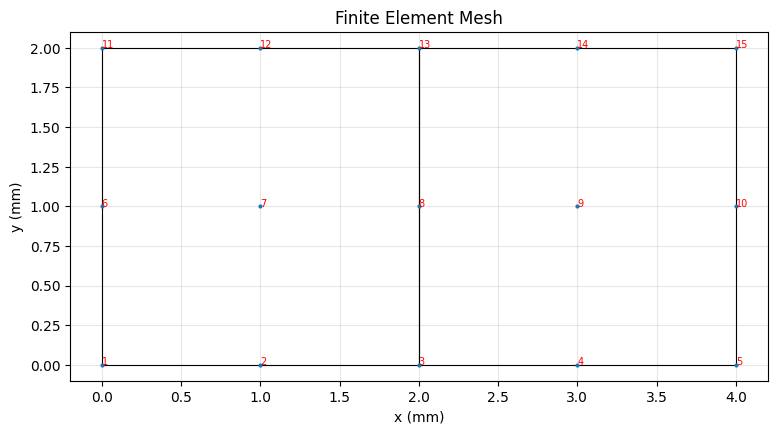

In [39]:
# @title EX01: mesh + dof check
def run_simple_mesh_example():
    Lx = 4.0
    Ly = 2.0
    nx = 2
    ny = 1

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    print("Simple mesh example")
    print(f"Nx = {Nx}, Ny = {Ny}")
    print(f"Number of nodes = {len(nodes)}")
    print(f"Number of active nodes = {sum(data['active'] for data in nodes.values())}")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")

    plot_mesh(nodes, elements, show_nodes=True, show_node_ids=True)

    return nodes, elements, boundary, dof_map, ndof
# =======================================================================================
nodes_ex1, elements_ex1, boundary_ex1, dof_map_ex1, ndof_ex1 = run_simple_mesh_example()

In [40]:
# @title EX02: element stiffness check
def run_one_element_stiffness_example():
    Lx = 4.0
    Ly = 2.0
    nx = 1
    ny = 1

    E = 200.0
    nu = 0.25
    t = 20.0

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    elem = elements[0]
    conn = elem["connectivity"]
    coords = np.array([nodes[n]["coords"] for n in conn])

    Ke, edofs = element_stiffness(coords, conn, dof_map, E, nu, t)

    print("One-element stiffness example")
    print(f"Ke shape = {Ke.shape}")
    print(f"Number of element DOFs = {len(edofs)}")
    print(f"Symmetric Ke? {np.allclose(Ke, Ke.T)}")
    print(f"Minimum diagonal entry = {np.min(np.diag(Ke))}")
    print(f"Maximum diagonal entry = {np.max(np.diag(Ke))}")

    return Ke, edofs

# =======================================================================================
Ke_ex2, edofs_ex2 = run_one_element_stiffness_example()

One-element stiffness example
Ke shape = (26, 26)
Number of element DOFs = 26
Symmetric Ke? True
Minimum diagonal entry = 1851.8518518518522
Maximum diagonal entry = 887045.2674897119


Rectangular plate edge load example
Nx = 9 Ny = 5
Number of elements = 8
ndof = 127
DOF map check passed.
Number of fixed DOFs = 15
Max deflection = -2.239469691112024
Min deflection = 0.0


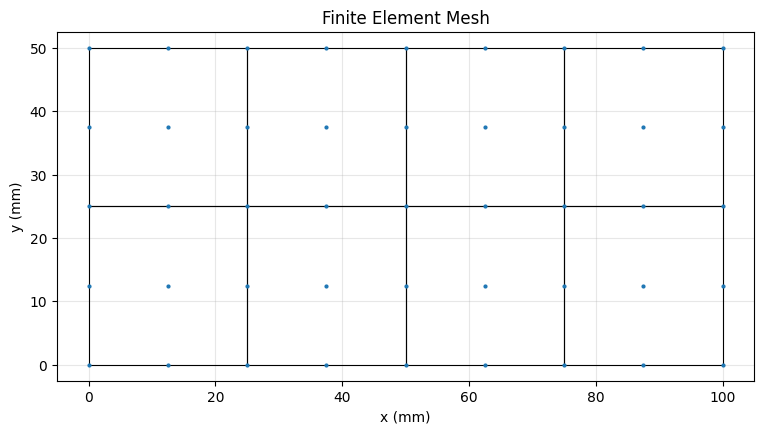

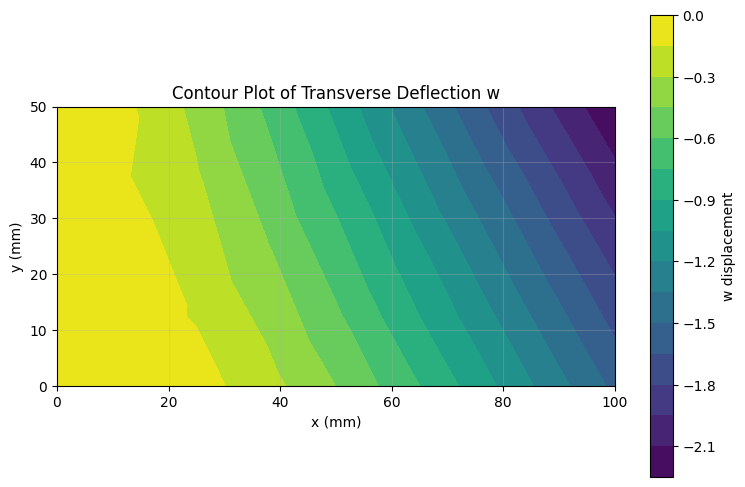

In [41]:
# @title EX03: clamped rectangular plate under edge line load
def apply_top_edge_line_load(F, elements, nodes, dof_map, qbar, Ly, tol=1e-8):
    """
    Applies line load to the outer top edge of a rectangular plate.
    """

    for elem in elements:
        conn = elem["connectivity"]

        edge_nodes = element_edge_nodes(conn, "top")
        edge_coords = np.array([nodes[n]["coords"] for n in edge_nodes])

        if np.all(np.isclose(edge_coords[:, 1], Ly, atol=tol)):
            Fe = edge_load_vector(edge_coords, qbar)
            edofs = edge_edofs(edge_nodes, dof_map)
            F = assemble_force(F, Fe, edofs)

    return F

def run_rectangular_plate_edge_load_example():
    Lx = 100.0
    Ly = 50.0

    nx = 4
    ny = 2

    E = 200.0
    nu = 0.25
    t = 20.0

    qbar = -1.0

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    F = apply_top_edge_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        qbar=qbar,
        Ly=Ly
    )

    # Clamp left edge only for a simple cantilever-like test
    fixed = fixed_dofs(
        boundary=boundary,
        dof_map=dof_map,
        clamped_sides=("left",)
    )

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    u = np.linalg.solve(K_bc, F_bc)

    print("Rectangular plate edge load example")
    print_solution_summary(nodes, elements, boundary, dof_map, ndof, u, fixed, nx, ny)

    plot_mesh(nodes, elements, show_nodes=True)
    plot_w_contour(nodes, dof_map, u)

    return u, nodes, elements, boundary, dof_map, ndof

# =======================================================================================
u_ex3, nodes_ex3, elements_ex3, boundary_ex3, dof_map_ex3, ndof_ex3 = run_rectangular_plate_edge_load_example()

In [42]:
# @title EX04: total line load check
def run_total_edge_load_check():
    Lx = 100.0
    Ly = 50.0

    nx = 4
    ny = 2

    qbar = -1.0

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    F = np.zeros(ndof)

    F = apply_top_edge_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        qbar=qbar,
        Ly=Ly
    )

    total_force = np.sum(F)
    expected_force = qbar * Lx

    print("Total edge load check")
    print(f"Computed total force = {total_force}")
    print(f"Expected total force = {expected_force}")
    print(f"Error = {total_force - expected_force}")

    assert np.isclose(total_force, expected_force)

    return total_force

# =======================================================================================
total_force_ex4 = run_total_edge_load_check()

Total edge load check
Computed total force = -99.99999999999999
Expected total force = -100.0
Error = 1.4210854715202004e-14


Project cutout load check
Number of elements = 126
ndof = 1638
Computed total cutout load = -250.0
Expected total cutout load = -250.0


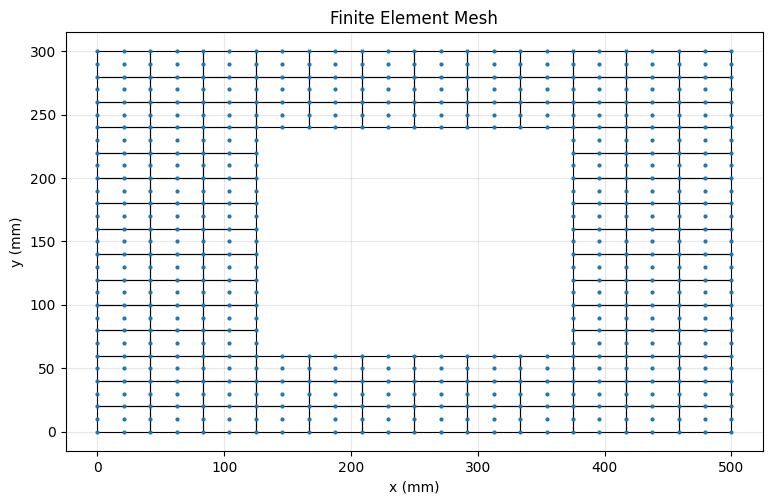

In [43]:
# @title EX05: cutout mesh & load check
def run_project_load_location_check():
    Lx = 500.0
    Ly = 300.0

    nx = 12
    ny = 15

    cutout = {
        "type": "rectangle",
        "cx": 250.0,
        "cy": 150.0,
        "hx": 125.0,
        "hy": 90.0,
        "tag": "cutout"
    }

    qbar = -1.0

    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=[cutout]
    )

    dof_map, ndof = assign_dofs(nodes, Nx)

    F = np.zeros(ndof)

    F = apply_cutout_top_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        cutout=cutout,
        qbar=qbar
    )

    total_force = np.sum(F)
    expected_force = qbar * (2 * cutout["hx"])

    print("Project cutout load check")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")
    print(f"Computed total cutout load = {total_force}")
    print(f"Expected total cutout load = {expected_force}")

    assert np.isclose(total_force, expected_force)

    plot_mesh(nodes, elements, show_nodes=True)

    return nodes, elements, boundary, dof_map, ndof, F

# =======================================================================================
nodes_ex5, elements_ex5, boundary_ex5, dof_map_ex5, ndof_ex5, F_ex5 = run_project_load_location_check()

## project problem execution

In [44]:
# @title function
# ============================================================
# 11. Project Problem Execution
# ============================================================
def run_project_problem(nx=12, ny=15, scale_plot=20, make_plots=True):
    """
    Runs the full project problem.

    nx, ny control mesh density.
    """

    # --------------------------------------------------------
    # Geometry
    # --------------------------------------------------------
    Lx = 500.0
    Ly = 300.0

    cutout = {
        "type": "rectangle",
        "cx": 250.0,
        "cy": 150.0,
        "hx": 125.0,
        "hy": 90.0,
        "tag": "cutout"
    }

    # --------------------------------------------------------
    # Material
    # --------------------------------------------------------
    E = 200000      # MPa
    nu = 0.25
    t = 20.0       # mm

    # --------------------------------------------------------
    # Loading (line load on cutout top)
    # --------------------------------------------------------
    qbar = -1000    # force per unit length

    # --------------------------------------------------------
    # Mesh
    # --------------------------------------------------------
    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=[cutout]
    )

    # --------------------------------------------------------
    # DOFs
    # --------------------------------------------------------
    dof_map, ndof = assign_dofs(nodes, Nx)

    # --------------------------------------------------------
    # Assembly
    # --------------------------------------------------------

    # --------------------------------------------------------
    # option a (original option)

    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    # --------------------------------------------------------
    # Apply cutout edge load
    # --------------------------------------------------------
    F = apply_cutout_top_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        cutout=cutout,
        qbar=qbar
    )
    print("Total applied force =", np.sum(F))
    print("Expected total force =", qbar * (2 * cutout["hx"]))

    # --------------------------------------------------------
    # Boundary conditions
    # --------------------------------------------------------

    # --------------------------------------------------------
    # option a (original option)

    fixed = fixed_dofs(
        boundary=boundary,
        dof_map=dof_map,
        clamped_sides=("left", "top")
    )

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    # --------------------------------------------------------
    # Solve
    # --------------------------------------------------------

    # option a (original option)
    u = np.linalg.solve(K_bc, F_bc)

    # --------------------------------------------------------
    # Output summary
    # --------------------------------------------------------
    print("\n=== PROJECT PROBLEM RESULTS ===\n")

    print_solution_summary(
        nodes=nodes,
        elements=elements,
        boundary=boundary,
        dof_map=dof_map,
        ndof=ndof,
        u=u,
        fixed=fixed,
        nx=nx,
        ny=ny
    )

    # --------------------------------------------------------
    # Point A evaluation
    # --------------------------------------------------------
    A = (375.0, 60.0)

    print()
    print_point_response(
        nodes=nodes,
        dof_map=dof_map,
        u=u,
        point=A,
        label="A"
    )

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------
    if make_plots:
        plot_mesh(nodes, elements, show_nodes=True)
        plot_mesh_with_point(nodes, elements, point=A, label="A")
        plot_w_contour(nodes, dof_map, u)
        plot_deformed_mesh(nodes, elements, dof_map, u, scale=scale_plot)

    return {
        "u": u,
        "nodes": nodes,
        "elements": elements,
        "boundary": boundary,
        "dof_map": dof_map,
        "ndof": ndof
    }

Total applied force = -250000.0
Expected total force = -250000.0

=== PROJECT PROBLEM RESULTS ===

Nx = 41 Ny = 51
Number of elements = 350
ndof = 4270
DOF map check passed.
Number of fixed DOFs = 273
Max deflection = -0.5260147361946871
Min deflection = 0.0022686310105732165

Closest node to A = 441
Coordinates = (np.float64(375.0), np.float64(60.0))
w at closest node = -0.351051829114727


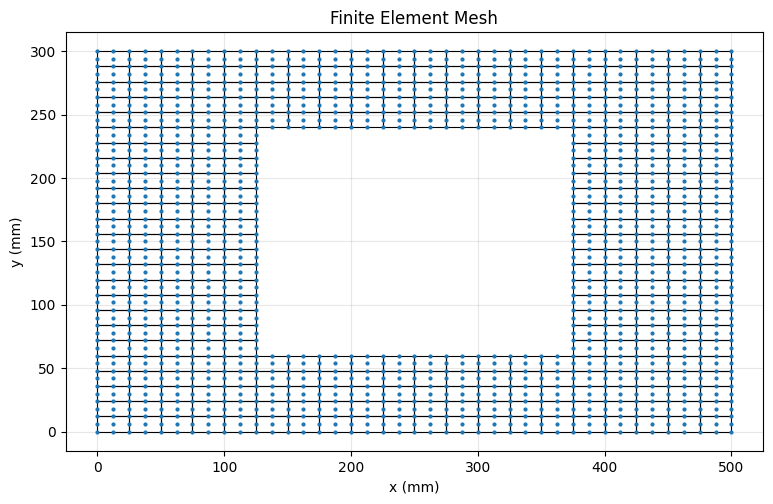

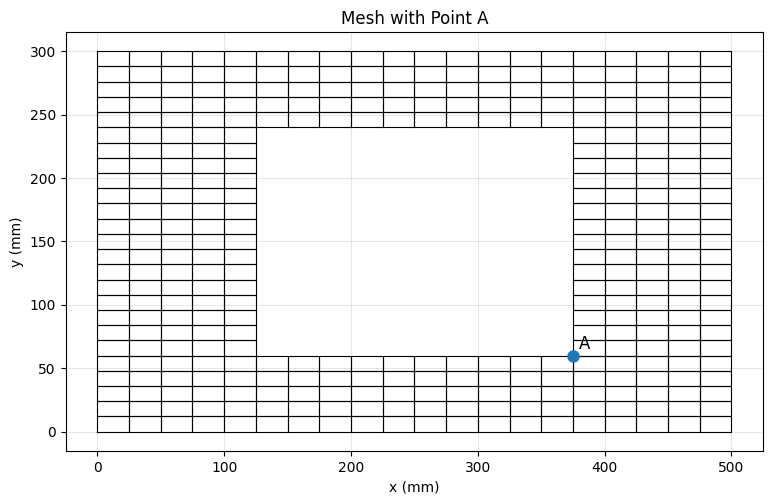

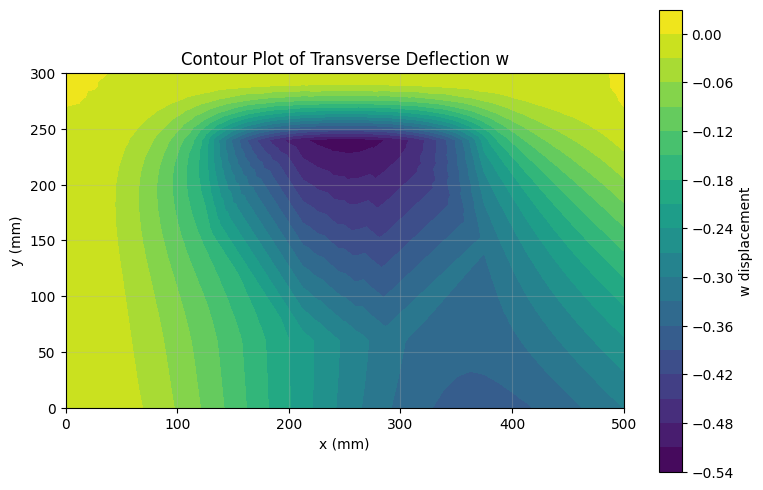

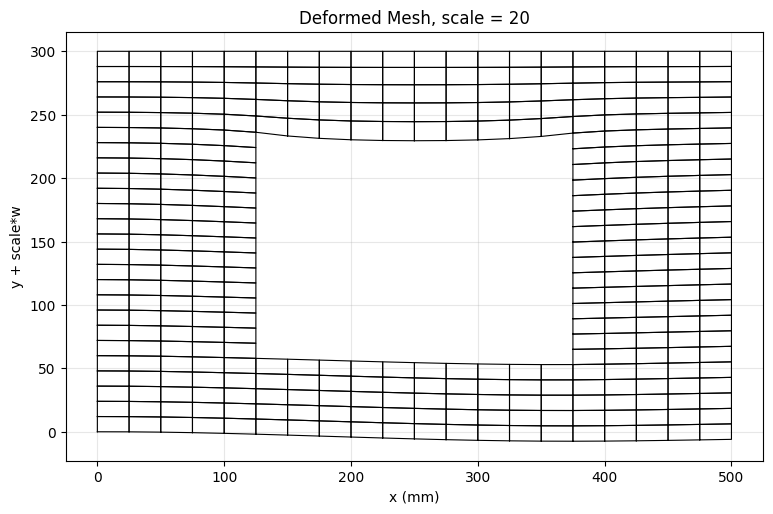

In [45]:
results = run_project_problem(nx=20, ny=25)

Total applied force = -250000.0
Expected total force = -250000.0

=== PROJECT PROBLEM RESULTS ===

Nx = 73 Ny = 91
Number of elements = 1134
ndof = 13230
DOF map check passed.
Number of fixed DOFs = 489
Max deflection = -0.5261537686333724
Min deflection = 0.0023358887020457674

Closest node to A = 1369
Coordinates = (np.float64(375.0), np.float64(60.0))
w at closest node = -0.34888089772813985


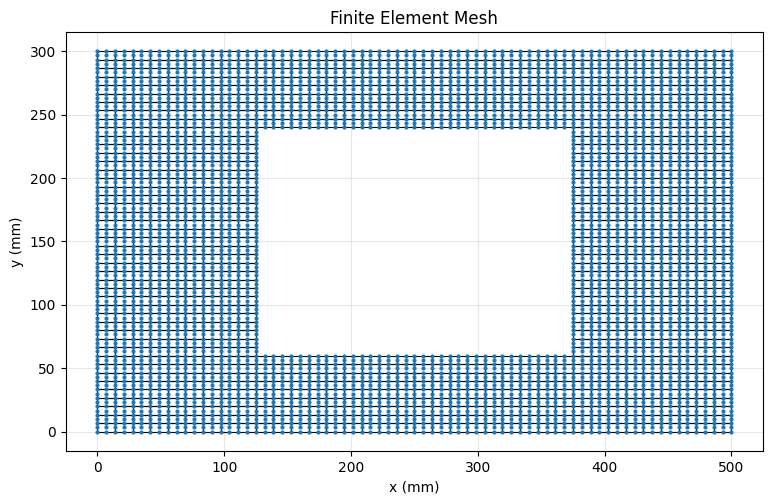

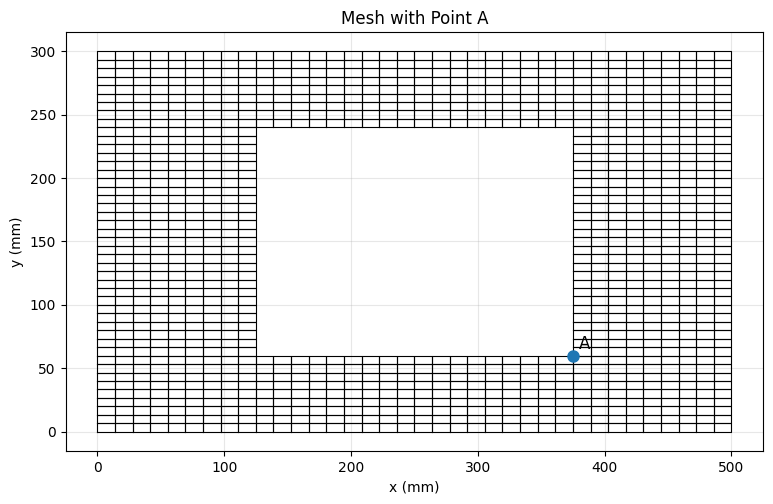

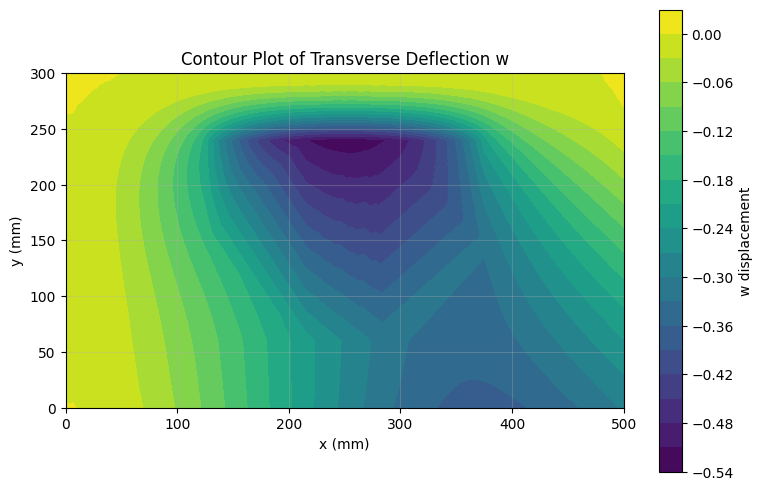

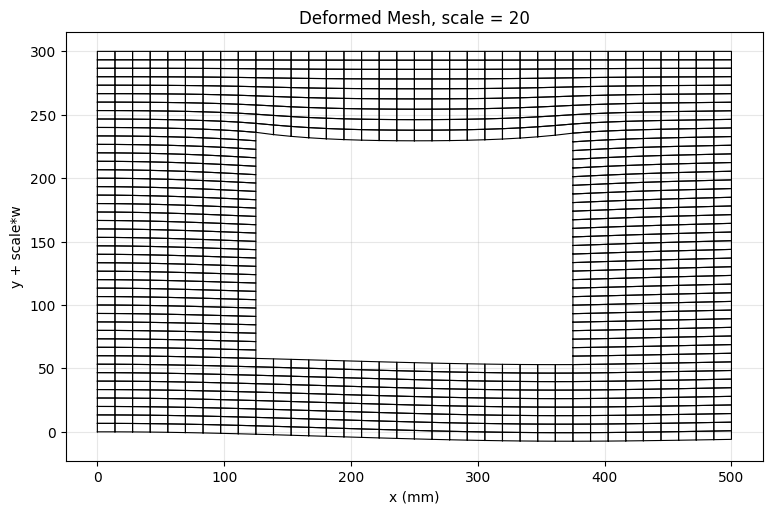

In [46]:
results = run_project_problem(nx=36, ny=45)

## mesh refinement

In [47]:
# @title mesh refinement studies
# ============================================================
# 12. Mesh Refinement Study
# ============================================================

def run_mesh_refinement_study(meshes=None, scale_plot=10):
    """
    Runs the project problem for multiple mesh densities and tracks:
        - number of elements
        - ndof
        - maximum downward deflection
        - w at Point A
    """

    if meshes is None:
        meshes = [
            (8, 10),
            (12, 15),
            (16, 20),
            (20, 25),
            (24, 30)
        ]

    results_table = []

    A = (375.0, 60.0)

    for nx, ny in meshes:
        print("\n" + "="*60)
        print(f"Running mesh refinement case: nx = {nx}, ny = {ny}")
        print("="*60)

        results = run_project_problem(
            nx=nx,
            ny=ny,
            scale_plot=scale_plot,
            make_plots=False
        )

        u = results["u"]
        nodes = results["nodes"]
        elements = results["elements"]
        dof_map = results["dof_map"]
        ndof = results["ndof"]

        node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

        w_min = np.min(w_vals)
        w_max = np.max(w_vals)

        closest_node, closest_coord, wA = closest_w_to_point(
            nodes=nodes,
            dof_map=dof_map,
            u=u,
            point=A
        )

        results_table.append({
            "nx": nx,
            "ny": ny,
            "elements": len(elements),
            "ndof": ndof,
            "w_min": w_min,
            "w_max": w_max,
            "node_A": closest_node,
            "x_A_node": closest_coord[0],
            "y_A_node": closest_coord[1],
            "w_A": wA
        })

    return results_table

def print_mesh_refinement_table(results_table):
    """
    Prints mesh refinement results in a clean table.
    """

    print("\nMESH REFINEMENT STUDY")
    print("-" * 95)
    print(
        f"{'nx':>5} {'ny':>5} {'elems':>8} {'ndof':>8} "
        f"{'w_min':>14} {'w_A':>14} {'A node':>8} {'A coords':>20}"
    )
    print("-" * 95)

    for r in results_table:
        coord_str = f"({r['x_A_node']:.1f}, {r['y_A_node']:.1f})"

        print(
            f"{r['nx']:5d} {r['ny']:5d} "
            f"{r['elements']:8d} {r['ndof']:8d} "
            f"{r['w_min']:14.6f} {r['w_A']:14.6f} "
            f"{r['node_A']:8d} {coord_str:>20}"
        )

    print("-" * 95)

def plot_mesh_refinement_results(results_table):
    """
    Plots convergence of max downward deflection and w at Point A.
    """

    elems = np.array([r["elements"] for r in results_table])
    ndofs = np.array([r["ndof"] for r in results_table])
    w_min = np.array([r["w_min"] for r in results_table])
    w_A = np.array([r["w_A"] for r in results_table])

    # Plot versus number of elements
    plt.figure(figsize=(8, 5))
    plt.plot(elems, w_min, marker="o", label="Maximum downward deflection")
    plt.plot(elems, w_A, marker="s", label="w at Point A")
    plt.xlabel("Number of elements")
    plt.ylabel("Deflection w")
    plt.title("Mesh Refinement Study: Deflection vs Elements")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # Plot versus DOFs
    plt.figure(figsize=(8, 5))
    plt.plot(ndofs, w_min, marker="o", label="Maximum downward deflection")
    plt.plot(ndofs, w_A, marker="s", label="w at Point A")
    plt.xlabel("Number of DOFs")
    plt.ylabel("Deflection w")
    plt.title("Mesh Refinement Study: Deflection vs DOFs")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

def compute_refinement_percent_changes(results_table):
    """
    Computes percent change between successive mesh refinement cases.
    """

    print("\nPERCENT CHANGE BETWEEN SUCCESSIVE MESHES")
    print("-" * 75)
    print(
        f"{'case':>10} {'w_min % change':>20} {'w_A % change':>20}"
    )
    print("-" * 75)

    for i in range(1, len(results_table)):
        prev = results_table[i - 1]
        curr = results_table[i]

        dw_min = 100 * abs((curr["w_min"] - prev["w_min"]) / prev["w_min"])
        dw_A = 100 * abs((curr["w_A"] - prev["w_A"]) / prev["w_A"])

        case_name = f"{prev['nx']}x{prev['ny']}→{curr['nx']}x{curr['ny']}"

        print(
            f"{case_name:>10} "
            f"{dw_min:20.3f} "
            f"{dw_A:20.3f}"
        )

    print("-" * 75)

In [48]:
# @title plot convergence
def plot_convergence(results_table):
    elems = np.array([r["elements"] for r in results_table])
    ndofs = np.array([r["ndof"] for r in results_table])
    w_min = np.array([r["w_min"] for r in results_table])
    w_A = np.array([r["w_A"] for r in results_table])

    # Use magnitude for cleaner convergence plot
    abs_w_min = np.abs(w_min)
    abs_w_A = np.abs(w_A)

    plt.figure(figsize=(8, 5))
    plt.plot(elems, abs_w_min, marker="o", label="|max downward deflection|")
    plt.plot(elems, abs_w_A, marker="s", label="|w at Point A|")
    plt.xlabel("Number of elements")
    plt.ylabel("Deflection magnitude")
    plt.title("Mesh Convergence: Deflection vs Number of Elements")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(ndofs, abs_w_min, marker="o", label="|max downward deflection|")
    plt.plot(ndofs, abs_w_A, marker="s", label="|w at Point A|")
    plt.xlabel("Number of DOFs")
    plt.ylabel("Deflection magnitude")
    plt.title("Mesh Convergence: Deflection vs DOFs")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


Running mesh refinement case: nx = 4, ny = 5
Total applied force = -250000.00000000003
Expected total force = -250000.0

=== PROJECT PROBLEM RESULTS ===

Nx = 9 Ny = 11
Number of elements = 14
ndof = 238
DOF map check passed.
Number of fixed DOFs = 57
Max deflection = -0.5580314773349301
Min deflection = 0.0

Closest node to A = 25
Coordinates = (np.float64(375.0), np.float64(60.0))
w at closest node = -0.3828257855747104

Running mesh refinement case: nx = 12, ny = 15
Total applied force = -250000.00000000003
Expected total force = -250000.0

=== PROJECT PROBLEM RESULTS ===

Nx = 25 Ny = 31
Number of elements = 126
ndof = 1638
DOF map check passed.
Number of fixed DOFs = 165
Max deflection = -0.5258513443527139
Min deflection = 0.002186640087621233

Closest node to A = 169
Coordinates = (np.float64(375.0), np.float64(60.0))
w at closest node = -0.35519045561228607

Running mesh refinement case: nx = 24, ny = 30
Total applied force = -250000.00000000006
Expected total force = -250000.

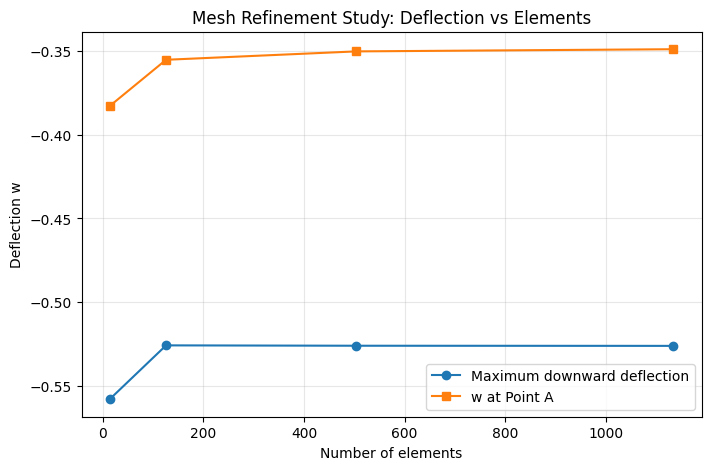

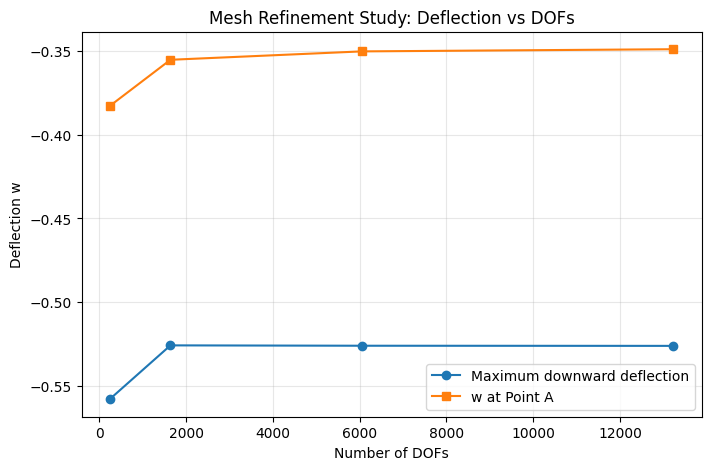

In [49]:
# @title refinement case
# nx is a multiple of 4
# ny is a multiple of 5
mesh_refinement_results = run_mesh_refinement_study(
    meshes = [
    (4, 5),
    # (8, 10),
    (12, 15),
    # (16,20),
    # (20,25),
    (24, 30),
    # (28, 35),
    # (32, 40),
    (36, 45),
    # (40, 50),
    # (44, 55),
    # (48, 60)
    ],
    scale_plot=10
)

print_mesh_refinement_table(mesh_refinement_results)
compute_refinement_percent_changes(mesh_refinement_results)
plot_mesh_refinement_results(mesh_refinement_results)

## localized mesh refinement

### functions

In [50]:
# @title mesh refiner functions
# ============================================================
# Adaptive Localized Mesh Refinement Based on Deflection Gradient
# ============================================================

def element_w_average(elem, nodes, dof_map, u):
    """
    Average w over the Q8 nodes of one element.
    Center node is ignored because w is inactive there.
    """
    conn = elem["connectivity"]
    w_vals = []

    for n in conn[:8]:  # Q8 nodes only
        d = dof_map[n]
        if d["w"] is not None:
            w_vals.append(u[d["w"]])

    return np.mean(w_vals)

def element_size_and_centroid(elem, nodes):
    conn = elem["connectivity"]
    coords = np.array([nodes[n]["coords"] for n in conn[:4]])  # corner nodes only

    centroid = coords.mean(axis=0)

    x_vals = coords[:, 0]
    y_vals = coords[:, 1]

    hx = np.max(x_vals) - np.min(x_vals)
    hy = np.max(y_vals) - np.min(y_vals)

    return centroid, hx, hy

def compute_deflection_gradient_indicator(nodes, elements, dof_map, u):
    """
    Computes a simple element-wise refinement indicator.

    Indicator is based on:
        |average element deflection| / element size

    This is not an exact gradient, but it is a practical refinement indicator.
    """

    indicators = []

    for elem in elements:
        w_avg = element_w_average(elem, nodes, dof_map, u)
        centroid, hx, hy = element_size_and_centroid(elem, nodes)

        h = np.sqrt(hx**2 + hy**2)

        indicator = abs(w_avg) / h

        indicators.append({
            "element_id": elem["id"],
            "centroid": centroid,
            "indicator": indicator
        })

    return indicators

def select_high_gradient_regions(indicators, percentile=80):
    """
    Select elements whose indicator is above a chosen percentile.
    """

    values = np.array([item["indicator"] for item in indicators])
    threshold = np.percentile(values, percentile)

    selected = [
        item for item in indicators
        if item["indicator"] >= threshold
    ]

    return selected, threshold

def build_refined_edges_from_regions(L, base_edges, selected_regions, direction, refine_radius=25.0):
    """
    Adds extra mesh lines near high-gradient element centroids.

    direction:
        "x" or "y"
    """

    new_edges = list(base_edges)

    for region in selected_regions:
        x, y = region["centroid"]

        center = x if direction == "x" else y

        new_edges.append(center - refine_radius)
        new_edges.append(center)
        new_edges.append(center + refine_radius)

    # keep inside domain
    new_edges = [e for e in new_edges if 0.0 <= e <= L]

    # remove duplicates and sort
    new_edges = sorted(set(np.round(new_edges, 8)))

    return np.array(new_edges)

def adaptive_refined_edges_from_solution(
    Lx, Ly,
    nodes, elements, dof_map, u,
    cutout,
    percentile=80,
    refine_radius=25.0
):
    """
    Creates new x and y element edges based on high deflection-gradient regions.
    """

    indicators = compute_deflection_gradient_indicator(
        nodes, elements, dof_map, u
    )

    selected, threshold = select_high_gradient_regions(
        indicators,
        percentile=percentile
    )

    print(f"Refinement threshold = {threshold}")
    print(f"Number of selected elements = {len(selected)}")

    # Base edges must include outer boundaries and cutout boundaries
    x_base = np.array([
        0.0,
        cutout["cx"] - cutout["hx"],
        cutout["cx"] + cutout["hx"],
        Lx
    ])

    y_base = np.array([
        0.0,
        cutout["cy"] - cutout["hy"],
        cutout["cy"] + cutout["hy"],
        Ly
    ])

    x_edges = build_refined_edges_from_regions(
        L=Lx,
        base_edges=x_base,
        selected_regions=selected,
        direction="x",
        refine_radius=refine_radius
    )

    y_edges = build_refined_edges_from_regions(
        L=Ly,
        base_edges=y_base,
        selected_regions=selected,
        direction="y",
        refine_radius=refine_radius
    )

    return x_edges, y_edges, indicators, selected

def generate_mesh_from_edges(x_edges, y_edges, cutouts=None):
    """
    Generates a Q9 mesh from custom x/y element edge coordinates.
    """

    nx = len(x_edges) - 1
    ny = len(y_edges) - 1

    # Create Q9 grid coordinates
    x_grid = []
    for i in range(nx):
        x_grid.append(x_edges[i])
        x_grid.append(0.5 * (x_edges[i] + x_edges[i+1]))
    x_grid.append(x_edges[-1])

    y_grid = []
    for j in range(ny):
        y_grid.append(y_edges[j])
        y_grid.append(0.5 * (y_edges[j] + y_edges[j+1]))
    y_grid.append(y_edges[-1])

    Nx = len(x_grid)
    Ny = len(y_grid)

    nodes = {}
    node_id = 1

    for j in range(Ny):
        for i in range(Nx):
            nodes[node_id] = {
                "coords": (x_grid[i], y_grid[j]),
                "active": True
            }
            node_id += 1

    deactivate_nodes_in_cutouts(nodes, cutouts)

    elements = []
    eid = 1

    for ey in range(ny):
        for ex in range(nx):
            i = 2 * ex
            j = 2 * ey

            conn = get_q9_connectivity(i, j, Nx)

            if any(not nodes[n]["active"] for n in conn):
                continue

            centroid = element_centroid(nodes, conn)

            if centroid_inside_any_cutout(centroid, cutouts):
                continue

            elements.append({
                "id": eid,
                "type": "Q9",
                "connectivity": conn
            })

            eid += 1

    Lx = x_edges[-1]
    Ly = y_edges[-1]

    boundary = tag_boundaries(nodes, Lx, Ly, cutouts=cutouts)

    return nodes, elements, boundary, Nx, Ny


In [51]:
# @title run project

def run_project_problem_from_custom_mesh(
    nodes, elements, boundary, Nx,
    nx_label="adaptive",
    ny_label="adaptive",
    scale_plot=20,
    make_plots=True
):
    # --------------------------------------------------------
    # Material
    # --------------------------------------------------------
    E = 200000.0   # N/mm^2
    nu = 0.25
    t = 20.0       # mm

    # --------------------------------------------------------
    # Geometry / cutout
    # --------------------------------------------------------
    cutout = {
        "type": "rectangle",
        "cx": 250.0,
        "cy": 150.0,
        "hx": 125.0,
        "hy": 90.0,
        "tag": "cutout"
    }

    # --------------------------------------------------------
    # Loading
    # --------------------------------------------------------
    qbar = -1000.0   # N/mm

    # --------------------------------------------------------
    # DOFs
    # --------------------------------------------------------
    dof_map, ndof = assign_dofs(nodes, Nx)

    # --------------------------------------------------------
    # Assembly
    # --------------------------------------------------------
    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    # --------------------------------------------------------
    # Apply cutout top line load
    # --------------------------------------------------------
    F = apply_cutout_top_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        cutout=cutout,
        qbar=qbar
    )

    print("Total applied force =", np.sum(F))
    print("Expected total force =", qbar * (2 * cutout["hx"]))

    # --------------------------------------------------------
    # Boundary conditions: left and top clamped
    # --------------------------------------------------------
    fixed = fixed_dofs(
        boundary=boundary,
        dof_map=dof_map,
        clamped_sides=("left", "top")
    )

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    # --------------------------------------------------------
    # Solve
    # --------------------------------------------------------
    u = np.linalg.solve(K_bc, F_bc)

    # --------------------------------------------------------
    # Extract results
    # --------------------------------------------------------
    node_ids, coords, w_vals = extract_w_values(nodes, dof_map, u)

    A = (375.0, 60.0)
    closest_node, closest_coord, wA = closest_w_to_point(
        nodes=nodes,
        dof_map=dof_map,
        u=u,
        point=A
    )

    print("\n=== ADAPTIVE / LOCAL REFINED MESH RESULTS ===\n")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")
    print(f"Number of fixed DOFs = {len(fixed)}")
    print(f"Maximum downward deflection = {np.min(w_vals)}")
    print(f"Maximum upward deflection = {np.max(w_vals)}")
    print(f"Closest node to A = {closest_node}")
    print(f"Coordinates = {closest_coord}")
    print(f"w at A = {wA}")

    # --------------------------------------------------------
    # Plots
    # --------------------------------------------------------
    if make_plots:
        plot_mesh(nodes, elements, show_nodes=True)
        plot_mesh_with_point(nodes, elements, point=A, label="A")
        plot_w_contour(nodes, dof_map, u)
        plot_deformed_mesh(nodes, elements, dof_map, u, scale=scale_plot)

    return {
        "u": u,
        "nodes": nodes,
        "elements": elements,
        "boundary": boundary,
        "dof_map": dof_map,
        "ndof": ndof,
        "fixed": fixed,
        "w_min": np.min(w_vals),
        "w_max": np.max(w_vals),
        "w_A": wA,
        "node_A": closest_node,
        "coord_A": closest_coord
    }

### workflow

Total applied force = -250000.0
Expected total force = -250000.0

=== PROJECT PROBLEM RESULTS ===

Nx = 73 Ny = 91
Number of elements = 1134
ndof = 13230
DOF map check passed.
Number of fixed DOFs = 489
Max deflection = -0.5261537686333724
Min deflection = 0.0023358887020457674

Closest node to A = 1369
Coordinates = (np.float64(375.0), np.float64(60.0))
w at closest node = -0.34888089772813985
Refinement threshold = 0.018682720686108014
Number of selected elements = 227
Refined Nx = 161
Refined Ny = 85
Number of refined elements = 2060


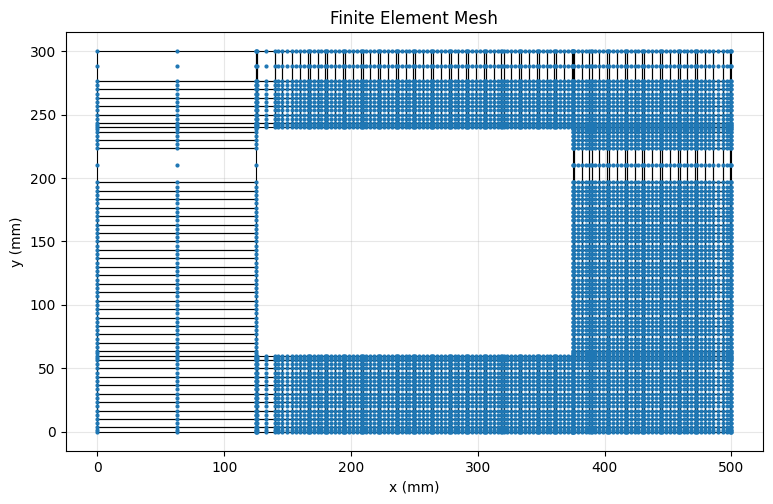

In [52]:
# @title original 36x45
# 1. Run coarse project problem first
results = run_project_problem(nx=36, ny=45, make_plots=False)

u = results["u"]
nodes = results["nodes"]
elements = results["elements"]
dof_map = results["dof_map"]

Lx = 500.0
Ly = 300.0

cutout = {
    "type": "rectangle",
    "cx": 250.0,
    "cy": 150.0,
    "hx": 125.0,
    "hy": 90.0,
    "tag": "cutout"
}

# 2. Build adaptive refined edges
x_edges, y_edges, indicators, selected = adaptive_refined_edges_from_solution(
    Lx=Lx,
    Ly=Ly,
    nodes=nodes,
    elements=elements,
    dof_map=dof_map,
    u=u,
    cutout=cutout,
    percentile=80,
    refine_radius=20.0
)

# 3. Generate refined mesh
nodes_ref, elements_ref, boundary_ref, Nx_ref, Ny_ref = generate_mesh_from_edges(
    x_edges=x_edges,
    y_edges=y_edges,
    cutouts=[cutout]
)

print("Refined Nx =", Nx_ref)
print("Refined Ny =", Ny_ref)
print("Number of refined elements =", len(elements_ref))

plot_mesh(nodes_ref, elements_ref, show_nodes=True)

Total applied force = -250000.0
Expected total force = -250000.0

=== ADAPTIVE / LOCAL REFINED MESH RESULTS ===

Number of elements = 2060
ndof = 23854
Number of fixed DOFs = 735
Maximum downward deflection = -0.5254069967832989
Maximum upward deflection = 0.0021094561230635225
Closest node to A = 3327
Coordinates = (np.float64(375.0), np.float64(60.0))
w at A = -0.3498370082481702


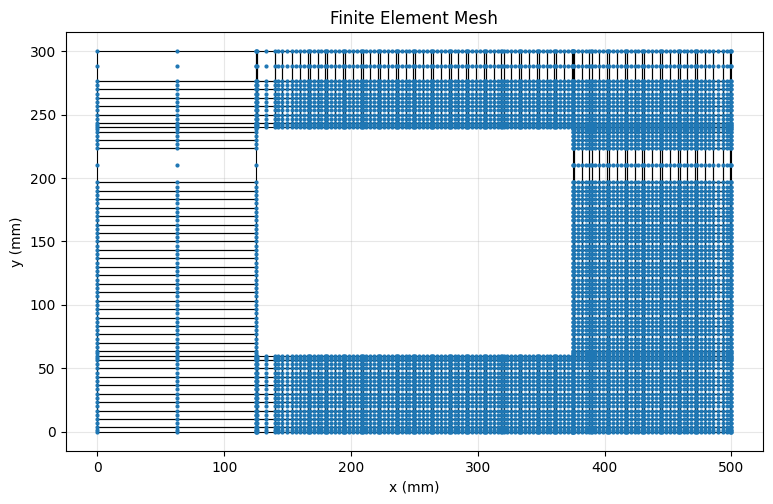

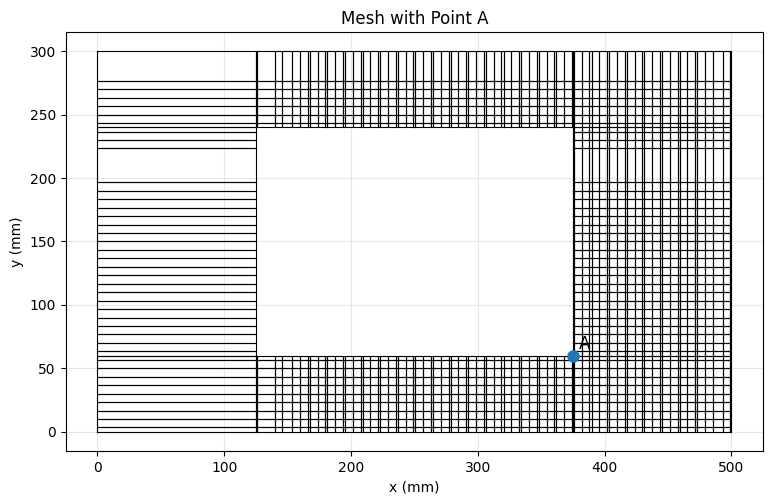

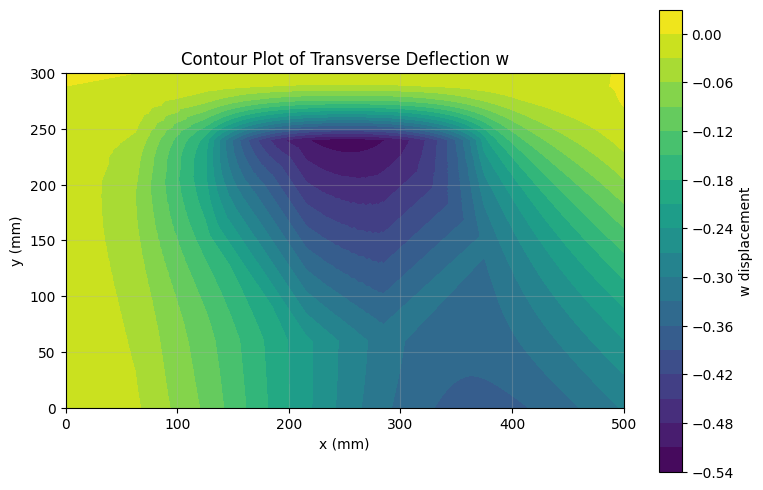

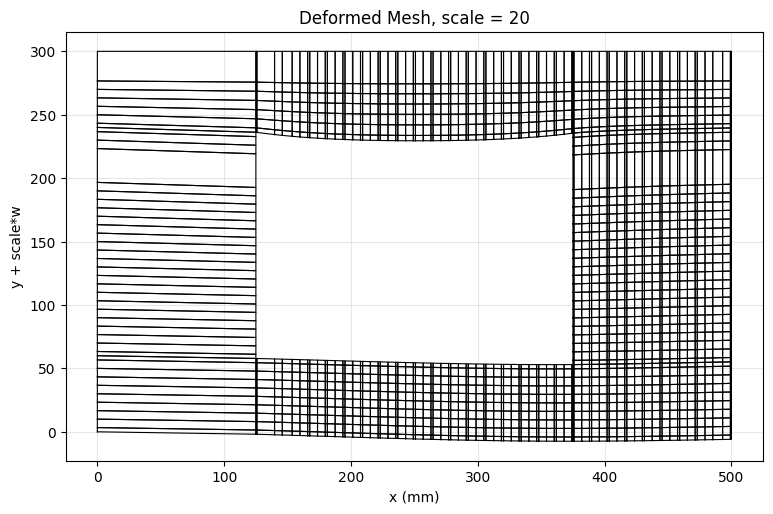

Adaptive mesh max downward deflection = -0.5254069967832989
Adaptive mesh w at A = -0.3498370082481702
Adaptive mesh ndof = 23854
Adaptive mesh elements = 2060


In [53]:
# @title refined 36x45
adaptive_results = run_project_problem_from_custom_mesh(
    nodes=nodes_ref,
    elements=elements_ref,
    boundary=boundary_ref,
    Nx=Nx_ref,
    scale_plot=20,
    make_plots=True
)

print("Adaptive mesh max downward deflection =", adaptive_results["w_min"])
print("Adaptive mesh w at A =", adaptive_results["w_A"])
print("Adaptive mesh ndof =", adaptive_results["ndof"])
print("Adaptive mesh elements =", len(adaptive_results["elements"]))

## patch tests

Patch tests were used to verify that the element formulation can reproduce basic exact displacement fields, such as rigid body motion and constant curvature. These tests verify the implementation of the shape functions, derivative mapping, and B-matrices, but they are separate from the final project loading and boundary condition problem.

In [54]:
# @title rigid body transverse translation (expect 0 strain and 0 internal force)
def patch_test_rigid_translation(nodes, elements, dof_map):
    u = np.zeros(max(
        dof for d in dof_map.values()
        for dof in [d["w"], d["theta1"], d["theta2"]]
        if dof is not None
    ) + 1)

    c = 2.0

    for nid, d in dof_map.items():
        if d["w"] is not None:
            u[d["w"]] = c
        u[d["theta1"]] = 0.0
        u[d["theta2"]] = 0.0

    print("Rigid translation patch test vector created.")
    return u

In [55]:
# @title rigid body rotation field (expect 0 bending strain and 0 shear strain)
def patch_test_rigid_rotation(nodes, dof_map, a=0.01, b=-0.02):
    ndof = max(
        dof for d in dof_map.values()
        for dof in [d["w"], d["theta1"], d["theta2"]]
        if dof is not None
    ) + 1

    u = np.zeros(ndof)

    for nid, d in dof_map.items():
        x, y = nodes[nid]["coords"]

        if d["w"] is not None:
            u[d["w"]] = a*x + b*y

        u[d["theta1"]] = a
        u[d["theta2"]] = b

    return u

In [56]:
# @title constant curvature / pure bending patch test
def patch_test_constant_curvature(nodes, dof_map, kx=0.001, ky=-0.0005, kxy=0.0):
    """
    Constant curvature patch test with compatible w and rotations.

    w = 1/2 kx x^2 + 1/2 ky y^2 + kxy x y

    theta1 = dw/dx = kx x + kxy y
    theta2 = dw/dy = ky y + kxy x

    Expected:
        kappa = [kx, ky, 2*kxy]
        gamma = [0, 0]
    """

    ndof = max(
        dof for d in dof_map.values()
        for dof in [d["w"], d["theta1"], d["theta2"]]
        if dof is not None
    ) + 1

    u = np.zeros(ndof)

    for nid, d in dof_map.items():
        x, y = nodes[nid]["coords"]

        w = 0.5 * kx * x**2 + 0.5 * ky * y**2 + kxy * x * y
        theta1 = kx * x + kxy * y
        theta2 = ky * y + kxy * x

        if d["w"] is not None:
            u[d["w"]] = w

        u[d["theta1"]] = theta1
        u[d["theta2"]] = theta2

    expected_kappa = np.array([kx, ky, 2 * kxy])
    expected_gamma = np.array([0.0, 0.0])

    return u, expected_kappa, expected_gamma

In [57]:
# @title function to eval element strains
def evaluate_element_strains(elem, nodes, dof_map, u, xi=0.0, eta=0.0):
    conn = elem["connectivity"]
    coords = np.array([nodes[n]["coords"] for n in conn])
    edofs = get_element_dofs(conn, dof_map)
    ue = u[edofs]

    # bending
    dN_dxi, dN_deta = shape_Q9_derivatives(xi, eta)
    J, detJ, dN_dx, dN_dy = jacobians(coords, dN_dxi, dN_deta)
    Bb = build_B_bending(dN_dx, dN_dy, conn, dof_map)
    kappa = Bb @ ue

    # shear
    N_theta = shape_Q9(xi, eta)
    J, detJ, dN_dx_w, dN_dy_w = map_Q8_derivatives_with_Q9_geometry(coords, xi, eta)
    Bs = build_B_shear(dN_dx_w, dN_dy_w, N_theta, conn, dof_map)
    gamma = Bs @ ue

    return kappa, gamma

In [58]:
# @title run all
def run_patch_tests(elem_id=0):
    Lx = 500.0
    Ly = 300.0
    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=12,
        ny=15,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    plot_mesh(nodes, elements, show_elem_ids=True)

    dof_map, ndof = assign_dofs(nodes, Nx)

    elem = elements[elem_id]

    # Test 1: rigid translation
    u_trans = patch_test_rigid_translation(nodes, elements, dof_map)
    kappa, gamma = evaluate_element_strains(elem, nodes, dof_map, u_trans)
    print("Rigid translation:")
    print("kappa =", kappa)
    print("gamma =", gamma)

    # Test 2: rigid rotation
    u_rot = patch_test_rigid_rotation(nodes, dof_map)
    kappa, gamma = evaluate_element_strains(elem, nodes, dof_map, u_rot)
    print("\nRigid rotation:")
    print("kappa =", kappa)
    print("gamma =", gamma)

    # Test 3: constant curvature / pure bending
    kx = 0.001
    ky = -0.0005
    kxy = 0.0002

    u_curv, expected_kappa, expected_gamma = patch_test_constant_curvature(
        nodes,
        dof_map,
        kx=kx,
        ky=ky,
        kxy=kxy
    )

    kappa, gamma = evaluate_element_strains(elem, nodes, dof_map, u_curv)

    print("\nConstant curvature / pure bending:")
    print("kappa =", kappa)
    print("expected kappa =", expected_kappa)
    print("gamma =", gamma)
    print("expected gamma =", expected_gamma)

    print("kappa check:", np.allclose(kappa, expected_kappa, atol=1e-10))
    print("gamma check:", np.allclose(gamma, expected_gamma, atol=1e-10))

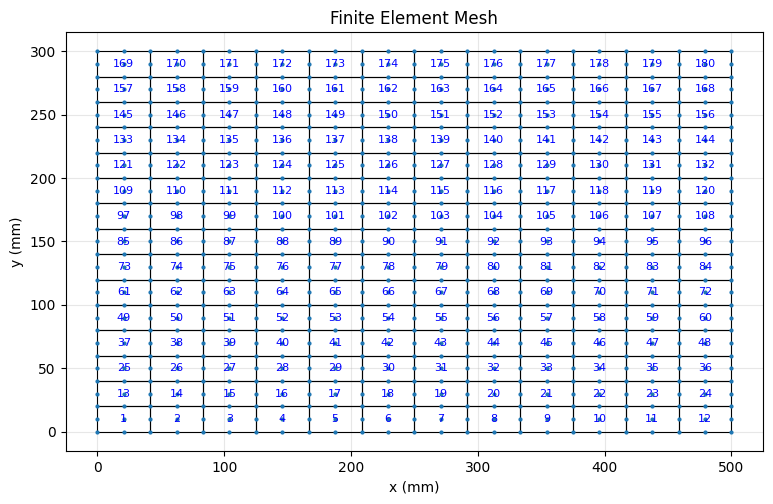

Rigid translation patch test vector created.
Rigid translation:
kappa = [0. 0. 0.]
gamma = [0. 0.]

Rigid rotation:
kappa = [0. 0. 0.]
gamma = [-1.90819582e-17  3.81639165e-17]

Constant curvature / pure bending:
kappa = [ 0.001  -0.0005  0.0004]
expected kappa = [ 0.001  -0.0005  0.0004]
gamma = [-1.11022302e-16  1.38777878e-16]
expected gamma = [0. 0.]
kappa check: True
gamma check: True


In [59]:
run_patch_tests(169)

expected results:

Rigid translation:
kappa ≈ [0, 0, 0]
gamma ≈ [0, 0]

Rigid rotation:
kappa ≈ [0, 0, 0]
gamma ≈ [0, 0]

Constant curvature:
kappa ≈ [kx, ky, 0]

## example cases

### case 1: quarter circular plate

In [60]:
# @title function
def square_to_quarter_disk(u, v, R):
    """
    Smooth mapping from unit square [0,1]x[0,1] to quarter disk.

    Boundaries:
        v = 0 -> x-axis
        u = 0 -> y-axis
        u = 1 or v = 1 -> circular arc
    """

    x = R * u * np.sqrt(1.0 - 0.5 * v**2)
    y = R * v * np.sqrt(1.0 - 0.5 * u**2)

    return x, y

def generate_quarter_circular_mesh(nx, ny, R):
    """
    Generates Q9 mesh for one quadrant of a circular plate.
    """

    Nx = 2 * nx + 1
    Ny = 2 * ny + 1

    nodes = {}
    node_id = 1

    for j in range(Ny):
        v = j / (Ny - 1)

        for i in range(Nx):
            u = i / (Nx - 1)

            x, y = square_to_quarter_disk(u, v, R)

            nodes[node_id] = {
                "coords": (x, y),
                "active": True
            }

            node_id += 1

    elements = []
    eid = 1

    for ey in range(ny):
        for ex in range(nx):
            i = 2 * ex
            j = 2 * ey

            conn = get_q9_connectivity(i, j, Nx)

            elements.append({
                "id": eid,
                "type": "Q9",
                "connectivity": conn
            })

            eid += 1

    # Boundary tags
    boundary = {
        "x_sym": [],
        "y_sym": [],
        "arc": [],
        "center": []
    }

    tol = 1e-8

    for nid, data in nodes.items():
        x, y = data["coords"]
        r = np.sqrt(x**2 + y**2)

        if np.isclose(y, 0.0, atol=tol):
            boundary["x_sym"].append(nid)

        if np.isclose(x, 0.0, atol=tol):
            boundary["y_sym"].append(nid)

        if np.isclose(r, R, atol=tol):
            boundary["arc"].append(nid)

        if np.isclose(x, 0.0, atol=tol) and np.isclose(y, 0.0, atol=tol):
            boundary["center"].append(nid)

    return nodes, elements, boundary, Nx, Ny

def fixed_dofs_circular_plate(boundary, dof_map):
    fixed = []

    # Clamped circular edge
    for nid in boundary["arc"]:
        d = dof_map[nid]

        if d["w"] is not None:
            fixed.append(d["w"])

        fixed.append(d["theta1"])
        fixed.append(d["theta2"])

    # Symmetry along x-axis: theta2 = 0
    for nid in boundary["x_sym"]:
        d = dof_map[nid]
        fixed.append(d["theta2"])

    # Symmetry along y-axis: theta1 = 0
    for nid in boundary["y_sym"]:
        d = dof_map[nid]
        fixed.append(d["theta1"])

    return sorted(set(fixed))

def apply_center_point_load(F, boundary, dof_map, P_full):
    """
    Applies a concentrated load at the center of a quarter circular plate.

    P_full is the load on the full circular plate.
    Quarter model receives P_full / 4.
    """

    center_nodes = boundary["center"]

    if len(center_nodes) != 1:
        raise ValueError("Expected exactly one center node.")

    center_node = center_nodes[0]
    w_dof = dof_map[center_node]["w"]

    if w_dof is None:
        raise ValueError("Center node does not have active w DOF.")

    F[w_dof] += -P_full / 4.0

    return F

def run_circular_plate_center_load_test(nx=8, ny=8, make_plots=True):
    """
    Clamped circular plate with center point load.

    Exact thin-plate check:
        w0 = -P R^2 / (16*pi*D)
    """

    # Geometry/material
    R = 5.0
    E = 200000.0
    nu = 0.25

    # Use thin plate so comparison to thin plate theory is reasonable
    t = 0.10

    # Full-plate concentrated load
    P = 1.0

    # Mesh
    nodes, elements, boundary, Nx, Ny = generate_quarter_circular_mesh(
        nx=nx,
        ny=ny,
        R=R
    )

    # DOFs
    dof_map, ndof = assign_dofs(nodes, Nx)

    # Assembly
    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    # Load
    F = apply_center_point_load(
        F=F,
        boundary=boundary,
        dof_map=dof_map,
        P_full=P
    )

    # Boundary conditions
    fixed = fixed_dofs_circular_plate(boundary, dof_map)

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    # Solve
    u = np.linalg.solve(K_bc, F_bc)

    # Extract center displacement
    center_node = boundary["center"][0]
    w_center = u[dof_map[center_node]["w"]]

    # Exact thin plate solution
    D = E * t**3 / (12.0 * (1.0 - nu**2))
    w_exact = -P * R**2 / (16.0 * np.pi * D)

    normalized_num = abs(w_center) * 16.0 * np.pi * D / (P * R**2)

    print("\n=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===\n")
    print(f"nx = {nx}, ny = {ny}")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")
    print(f"w_center numerical = {w_center}")
    print(f"w_center exact thin plate = {w_exact}")
    print(f"normalized numerical value = {normalized_num}")
    print("target normalized value ≈ 1.0")

    if make_plots:
        plot_mesh(nodes, elements, show_nodes=True)
        plot_w_contour(nodes, dof_map, u)

    return {
        "u": u,
        "nodes": nodes,
        "elements": elements,
        "boundary": boundary,
        "dof_map": dof_map,
        "ndof": ndof,
        "w_center": w_center,
        "w_exact": w_exact,
        "normalized": normalized_num
    }




=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===

nx = 8, ny = 8
Number of elements = 64
ndof = 803
w_center numerical = -0.02784357615433508
w_center exact thin plate = -0.02797645484037222
normalized numerical value = 0.9952503386581567
target normalized value ≈ 1.0


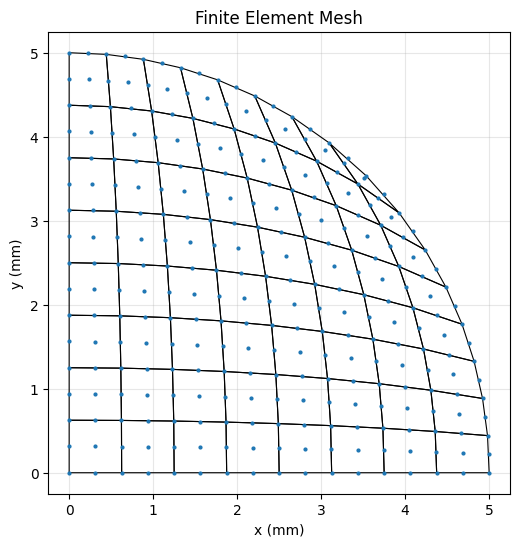

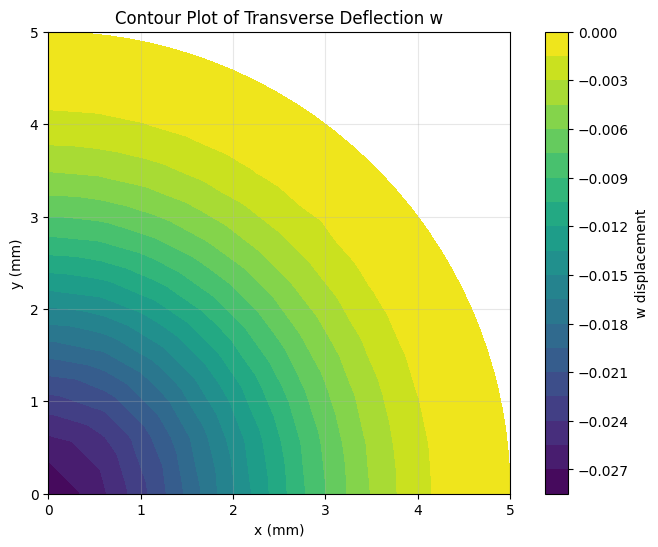

In [61]:
circ_results = run_circular_plate_center_load_test(nx=8,ny=8, make_plots=True)

In [62]:
# @title convergence
def run_circular_plate_convergence():
    meshes = [
        (2, 2),
        (4, 4),
        (8, 8),
        (12, 12),
        (16, 16)
    ]

    results = []

    for nx, ny in meshes:
        res = run_circular_plate_center_load_test(
            nx=nx,
            ny=ny,
            make_plots=False
        )

        results.append({
            "nx": nx,
            "ny": ny,
            "elements": len(res["elements"]),
            "ndof": res["ndof"],
            "w_center": res["w_center"],
            "w_exact": res["w_exact"],
            "normalized": res["normalized"]
        })

    print("\nCIRCULAR PLATE CONVERGENCE")
    print("-" * 80)
    print(f"{'nx':>5} {'ny':>5} {'elems':>8} {'ndof':>8} {'w_center':>16} {'normalized':>14}")
    print("-" * 80)

    for r in results:
        print(
            f"{r['nx']:5d} {r['ny']:5d} "
            f"{r['elements']:8d} {r['ndof']:8d} "
            f"{r['w_center']:16.6e} {r['normalized']:14.6f}"
        )

    print("-" * 80)

    return results


def plot_circular_plate_convergence(results):
    elems = np.array([r["elements"] for r in results])
    normalized = np.array([r["normalized"] for r in results])

    plt.figure(figsize=(8, 5))
    plt.plot(elems, normalized, marker="o", label="Numerical")
    plt.axhline(1.0, linestyle="--", label="Thin plate exact target")
    plt.xlabel("Number of elements")
    plt.ylabel(r"$16\pi D |w_0|/(P R^2)$")
    plt.title("Circular Plate Patch/Benchmark Test")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===

nx = 2, ny = 2
Number of elements = 4
ndof = 71
w_center numerical = -0.025350353733710765
w_center exact thin plate = -0.02797645484037222
normalized numerical value = 0.9061317410785091
target normalized value ≈ 1.0

=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===

nx = 4, ny = 4
Number of elements = 16
ndof = 227
w_center numerical = -0.027534850958734366
w_center exact thin plate = -0.02797645484037222
normalized numerical value = 0.9842151593489041
target normalized value ≈ 1.0

=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===

nx = 8, ny = 8
Number of elements = 64
ndof = 803
w_center numerical = -0.02784357615433508
w_center exact thin plate = -0.02797645484037222
normalized numerical value = 0.9952503386581567
target normalized value ≈ 1.0

=== CLAMPED CIRCULAR PLATE CENTER LOAD TEST ===

nx = 12, ny = 12
Number of elements = 144
ndof = 1731
w_center numerical = -0.027878466109406665
w_center exact thin plate = -0.027976454840372

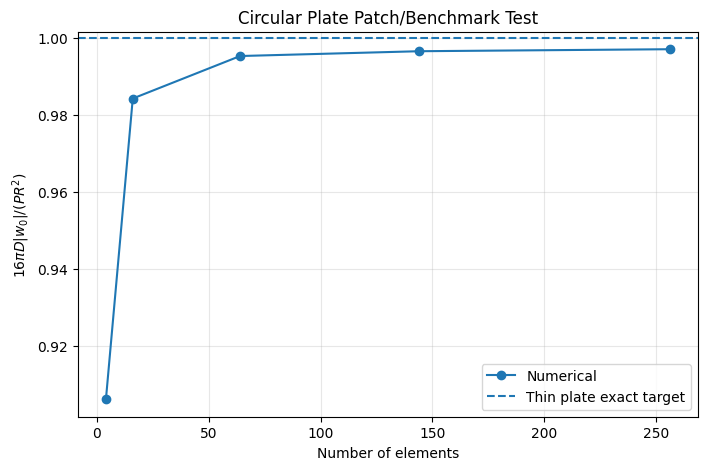

In [63]:
circular_convergence_results = run_circular_plate_convergence()

plot_circular_plate_convergence(circular_convergence_results)

The circular plate benchmark uses a different mesh generator and boundary-condition selector because the geometry is circular and the model uses symmetry boundaries. However, the same core solver routines are used, including the Q8/Q9 interpolation, Jacobian mapping, B-matrix construction, element stiffness calculation, quadrature, assembly, and solution procedure. Therefore, the benchmark still verifies the main finite element implementation used in the project problem.

```
assign_dofs()
shape_Q8()
shape_Q9()
jacobians()
build_B_bending()
build_B_shear()
build_D_matrix()
element_stiffness()
assemble_system()
bc()
```



### case 2: pinned plate with uniform loading

In [64]:
# @title functions
# ============================================================
# Simply Supported / Pinned Boundary Conditions
# ============================================================

def fixed_w_dofs_on_sides(boundary, dof_map, sides=("left", "right", "top", "bottom")):
    """
    For a simply supported / pinned plate edge:
        w = 0
        rotations are free

    This function fixes only the transverse displacement DOFs.
    """

    fixed = []

    for side in sides:
        for nid in boundary[side]:
            d = dof_map[nid]

            if d["w"] is not None:
                fixed.append(d["w"])

    return sorted(set(fixed))

# ============================================================
# Uniform Pressure Load
# ============================================================

def element_uniform_pressure_load(coords, conn, dof_map, q):
    """
    Consistent element load vector for uniform transverse pressure.

    q is force per unit area.
    Positive/negative sign follows your convention.
    """

    edofs = get_element_dofs(conn, dof_map)
    Fe = np.zeros(len(edofs))

    points, weights = gauss_2D(3)

    for (xi, eta), wt in zip(points, weights):

        # Q8 interpolation for w
        Nw = shape_Q8(xi, eta)

        # Geometry always uses Q9
        dN_dxi_geom, dN_deta_geom = shape_Q9_derivatives(xi, eta)
        J = jacobian(coords, dN_dxi_geom, dN_deta_geom)
        detJ, invJ = jacobian_inverse(J)

        col = 0

        for i, nid in enumerate(conn):
            d = dof_map[nid]

            if d["w"] is not None:
                # i = 0,...,7 for active Q8 w nodes
                Fe[col] += Nw[i] * q * detJ * wt
                col += 1

            # skip theta1 and theta2 force entries
            col += 2

    return Fe, edofs

def apply_uniform_pressure(F, elements, nodes, dof_map, q):
    """
    Applies uniform pressure load to all elements.
    """

    for elem in elements:
        conn = elem["connectivity"]
        coords = np.array([nodes[n]["coords"] for n in conn])

        Fe, edofs = element_uniform_pressure_load(
            coords=coords,
            conn=conn,
            dof_map=dof_map,
            q=q
        )

        F = assemble_force(F, Fe, edofs)

    return F



In [65]:
# @title analytical solution
# ============================================================
# Analytical Solution: Simply Supported Rectangular Plate
# Uniform Load
# ============================================================

def analytical_ss_rect_uniform_w(x, y, a, b, E, nu, t, q, n_terms=25):
    """
    Analytical thin-plate Navier solution for simply supported rectangular plate
    under uniform pressure q.

    Uses odd m,n terms only.
    """

    D = E * t**3 / (12.0 * (1.0 - nu**2))

    w = 0.0

    for m in range(1, 2*n_terms, 2):
        for n in range(1, 2*n_terms, 2):

            denom = (
                m * n *
                ((m / a)**2 + (n / b)**2)**2
            )

            term = (
                16.0 * q /
                (np.pi**6 * D * denom)
            )

            term *= np.sin(m * np.pi * x / a)
            term *= np.sin(n * np.pi * y / b)

            w += term

    return w

In [66]:
# @title run case 1
# ============================================================
# Run Test Case 1:
# Uniformly Loaded Simply Supported Rectangular Plate
# ============================================================

def run_ss_rect_uniform_load_test(nx=12, ny=12, make_plots=True):
    """
    Verification case:
    Simply supported rectangular plate with uniform pressure.

    Essential BC:
        w = 0 on all edges

    Analytical solution:
        Navier series for thin rectangular plate.
    """

    # Geometry
    Lx = 100.0
    Ly = 100.0

    # Material
    E = 200000.0
    nu = 0.25
    t = 1.0

    # Uniform pressure
    q = -1.0

    # Mesh
    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    # DOFs
    dof_map, ndof = assign_dofs(nodes, Nx)

    # Assembly
    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    # Apply uniform pressure
    F = apply_uniform_pressure(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        q=q
    )

    # Simply supported / pinned: w = 0 on all sides
    fixed = fixed_w_dofs_on_sides(
        boundary=boundary,
        dof_map=dof_map,
        sides=("left", "right", "top", "bottom")
    )

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    # Solve
    u = np.linalg.solve(K_bc, F_bc)

    # Center point
    center = (Lx / 2.0, Ly / 2.0)

    center_node, center_coord, w_center_num = closest_w_to_point(
        nodes=nodes,
        dof_map=dof_map,
        u=u,
        point=center
    )

    w_center_exact = analytical_ss_rect_uniform_w(
        x=center[0],
        y=center[1],
        a=Lx,
        b=Ly,
        E=E,
        nu=nu,
        t=t,
        q=q,
        n_terms=35
    )

    error = abs((w_center_num - w_center_exact) / w_center_exact) * 100.0

    print("\n=== SIMPLY SUPPORTED RECTANGULAR PLATE: UNIFORM LOAD ===\n")
    print(f"nx = {nx}, ny = {ny}")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")
    print(f"Total applied load numerical = {np.sum(F)}")
    print(f"Total applied load exact = {q * Lx * Ly}")
    print(f"Center node = {center_node}")
    print(f"Center node coordinates = {center_coord}")
    print(f"w_center numerical = {w_center_num}")
    print(f"w_center analytical = {w_center_exact}")
    print(f"percent error = {error:.4f}%")

    if make_plots:
        plot_mesh(nodes, elements, show_nodes=True)
        plot_w_contour(nodes, dof_map, u)

    return {
        "u": u,
        "nodes": nodes,
        "elements": elements,
        "boundary": boundary,
        "dof_map": dof_map,
        "ndof": ndof,
        "w_center_num": w_center_num,
        "w_center_exact": w_center_exact,
        "error_percent": error
    }


=== SIMPLY SUPPORTED RECTANGULAR PLATE: UNIFORM LOAD ===

nx = 12, ny = 12
Number of elements = 144
ndof = 1731
Total applied load numerical = -9999.999999999996
Total applied load exact = -10000.0
Center node = 313
Center node coordinates = (np.float64(50.0), np.float64(50.0))
w_center numerical = -23.073034061189027
w_center analytical = -22.85073375996
percent error = 0.9728%


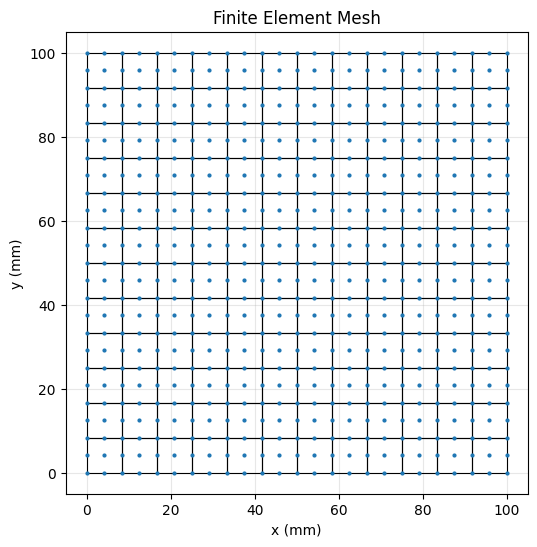

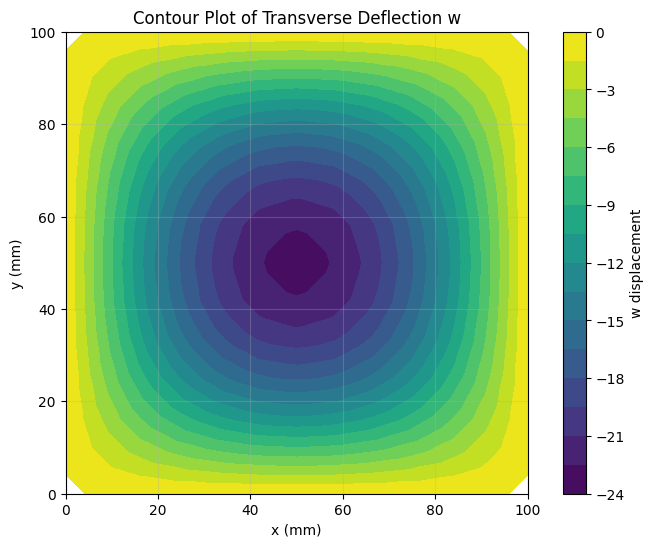

In [67]:
ss_uniform_results = run_ss_rect_uniform_load_test(nx=12, ny=12, make_plots=True)

In [68]:
# @title convergence
def run_ss_rect_uniform_convergence():
    meshes = [
        (4, 4),
        (8, 8),
        (12, 12),
        (16, 16),
        (20, 20)
    ]

    results = []

    for nx, ny in meshes:
        res = run_ss_rect_uniform_load_test(
            nx=nx,
            ny=ny,
            make_plots=False
        )

        results.append({
            "nx": nx,
            "ny": ny,
            "elements": len(res["elements"]),
            "ndof": res["ndof"],
            "w_center_num": res["w_center_num"],
            "w_center_exact": res["w_center_exact"],
            "error_percent": res["error_percent"]
        })

    print("\nSIMPLY SUPPORTED UNIFORM LOAD CONVERGENCE")
    print("-" * 95)
    print(
        f"{'nx':>5} {'ny':>5} {'elems':>8} {'ndof':>8} "
        f"{'w_num':>16} {'w_exact':>16} {'error %':>12}"
    )
    print("-" * 95)

    for r in results:
        print(
            f"{r['nx']:5d} {r['ny']:5d} "
            f"{r['elements']:8d} {r['ndof']:8d} "
            f"{r['w_center_num']:16.6e} "
            f"{r['w_center_exact']:16.6e} "
            f"{r['error_percent']:12.4f}"
        )

    print("-" * 95)

    # --------------------------------------------------------
    # Plot convergence
    # --------------------------------------------------------
    elems = np.array([r["elements"] for r in results])
    w_num = np.array([r["w_center_num"] for r in results])
    w_exact = np.array([r["w_center_exact"] for r in results])
    error = np.array([r["error_percent"] for r in results])

    plt.figure(figsize=(8, 5))
    plt.plot(elems, w_num, marker="o", label="FE numerical")
    plt.axhline(w_exact[0], linestyle="--", label="Analytical")
    plt.xlabel("Number of elements")
    plt.ylabel("Center deflection")
    plt.title("Simply Supported Uniform Load: Center Deflection Convergence")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(elems, error, marker="o")
    plt.xlabel("Number of elements")
    plt.ylabel("Percent error (%)")
    plt.title("Simply Supported Uniform Load: Error Convergence")
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


=== SIMPLY SUPPORTED RECTANGULAR PLATE: UNIFORM LOAD ===

nx = 4, ny = 4
Number of elements = 16
ndof = 227
Total applied load numerical = -10000.0
Total applied load exact = -10000.0
Center node = 41
Center node coordinates = (np.float64(50.0), np.float64(50.0))
w_center numerical = -23.5397695435287
w_center analytical = -22.85073375996
percent error = 3.0154%

=== SIMPLY SUPPORTED RECTANGULAR PLATE: UNIFORM LOAD ===

nx = 8, ny = 8
Number of elements = 64
ndof = 803
Total applied load numerical = -10000.0
Total applied load exact = -10000.0
Center node = 145
Center node coordinates = (np.float64(50.0), np.float64(50.0))
w_center numerical = -23.11047052586416
w_center analytical = -22.85073375996
percent error = 1.1367%

=== SIMPLY SUPPORTED RECTANGULAR PLATE: UNIFORM LOAD ===

nx = 12, ny = 12
Number of elements = 144
ndof = 1731
Total applied load numerical = -9999.999999999996
Total applied load exact = -10000.0
Center node = 313
Center node coordinates = (np.float64(50.0), np.f

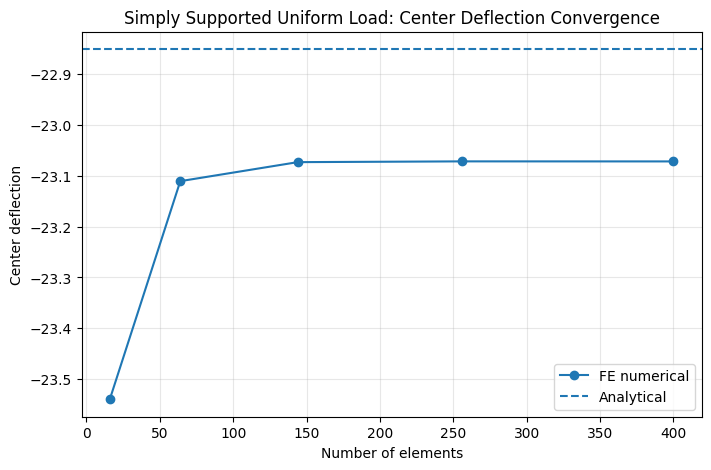

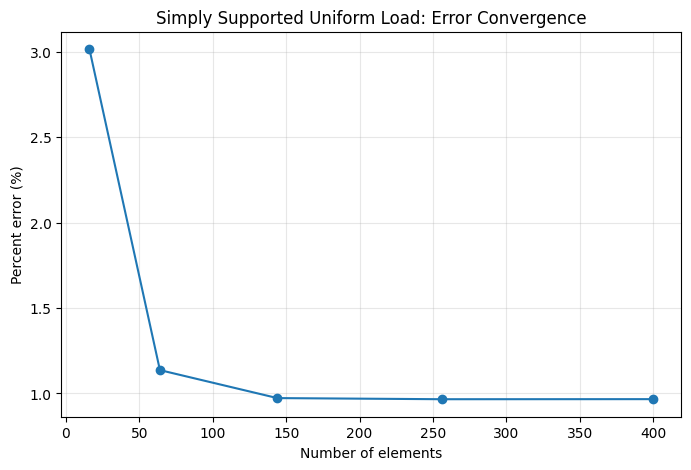

In [69]:
ss_uniform_convergence = run_ss_rect_uniform_convergence()

### case 3: cantilever plate with line loading @ end

In [70]:
# @title functions
def right_edge_nodes(conn):
    """
    Q9 ordering:
        [BL, BR, TR, TL, MB, MR, MT, ML, C]

    Right edge is:
        BR -- MR -- TR
    """
    return [conn[1], conn[5], conn[2]]

def is_on_right_edge(edge_coords, Lx, tol=1e-8):
    """
    Checks if a 3-node quadratic edge lies on x = Lx.
    """

    return all(abs(x - Lx) < tol for x, y in edge_coords)

def apply_right_edge_line_load(F, elements, nodes, dof_map, Lx, qbar):
    """
    Applies transverse line load along the right edge of the plate.

    qbar:
        force per unit length along the edge.
    """

    for elem in elements:
        conn = elem["connectivity"]

        edge_nodes = right_edge_nodes(conn)
        edge_coords = np.array([nodes[n]["coords"] for n in edge_nodes])

        if is_on_right_edge(edge_coords, Lx):
            fe_edge = edge_load_vector(edge_coords, qbar)
            edofs_edge = edge_edofs(edge_nodes, dof_map)

            F = assemble_force(F, fe_edge, edofs_edge)

    return F

In [71]:
# @title analytical solution
def analytical_cantilever_tip_deflection(L, b, E, nu, t, qbar, theory="timoshenko"):
    """
    Approximate analytical solution for a cantilever plate strip.

    Plate is treated as a beam:
        length = L
        width = b
        thickness = t

    qbar:
        line load along free edge, force per unit length.
        Total force P = qbar * b.

    theory:
        "euler" or "timoshenko"
    """

    P = qbar * b

    I = b * t**3 / 12.0
    A = b * t

    G = E / (2.0 * (1.0 + nu))
    kappa = 5.0 / 6.0

    w_bending = P * L**3 / (3.0 * E * I)

    if theory == "euler":
        return w_bending

    elif theory == "timoshenko":
        w_shear = P * L / (kappa * G * A)
        return w_bending + w_shear

    else:
        raise ValueError("theory must be 'euler' or 'timoshenko'")

In [72]:
# @title run case 2

def run_cantilever_plate_strip_test(nx=12, ny=4, make_plots=True):
    """
    Verification case:
    Cantilever plate strip with transverse line load at the free end.

    Boundary conditions:
        left edge clamped
        right, top, bottom free

    Analytical comparison:
        Timoshenko beam theory using P = qbar * b
    """

    # --------------------------------------------------------
    # Geometry
    # --------------------------------------------------------
    Lx = 100.0   # length
    Ly = 20.0    # width

    # --------------------------------------------------------
    # Material
    # --------------------------------------------------------
    E = 200000.0
    nu = 0.25
    t = 5.0

    # --------------------------------------------------------
    # Load
    # --------------------------------------------------------
    qbar = -10.0   # force per unit length along free edge

    # --------------------------------------------------------
    # Mesh
    # --------------------------------------------------------
    nodes, elements, boundary, Nx, Ny = generate_mesh(
        nx=nx,
        ny=ny,
        Lx=Lx,
        Ly=Ly,
        cutouts=None
    )

    # --------------------------------------------------------
    # DOFs
    # --------------------------------------------------------
    dof_map, ndof = assign_dofs(nodes, Nx)

    # --------------------------------------------------------
    # Assembly
    # --------------------------------------------------------
    K, F = assemble_system(
        nodes=nodes,
        elements=elements,
        dof_map=dof_map,
        ndof=ndof,
        E=E,
        nu=nu,
        t=t
    )

    # --------------------------------------------------------
    # Apply right edge line load
    # --------------------------------------------------------
    F = apply_right_edge_line_load(
        F=F,
        elements=elements,
        nodes=nodes,
        dof_map=dof_map,
        Lx=Lx,
        qbar=qbar
    )

    # --------------------------------------------------------
    # Boundary conditions: left edge clamped
    # --------------------------------------------------------
    fixed = fixed_dofs(
        boundary=boundary,
        dof_map=dof_map,
        clamped_sides=("left",)
    )

    K_bc, F_bc = bc(K.copy(), F.copy(), fixed)

    # --------------------------------------------------------
    # Solve
    # --------------------------------------------------------
    u = np.linalg.solve(K_bc, F_bc)

    # --------------------------------------------------------
    # Compare tip deflection at center of free edge
    # --------------------------------------------------------
    tip_point = (Lx, Ly / 2.0)

    tip_node, tip_coord, w_tip_num = closest_w_to_point(
        nodes=nodes,
        dof_map=dof_map,
        u=u,
        point=tip_point
    )

    w_tip_euler = analytical_cantilever_tip_deflection(
        L=Lx,
        b=Ly,
        E=E,
        nu=nu,
        t=t,
        qbar=qbar,
        theory="euler"
    )

    w_tip_timoshenko = analytical_cantilever_tip_deflection(
        L=Lx,
        b=Ly,
        E=E,
        nu=nu,
        t=t,
        qbar=qbar,
        theory="timoshenko"
    )

    error_timo = abs((w_tip_num - w_tip_timoshenko) / w_tip_timoshenko) * 100.0

    print("\n=== CANTILEVER PLATE STRIP LINE LOAD TEST ===\n")
    print(f"nx = {nx}, ny = {ny}")
    print(f"Number of elements = {len(elements)}")
    print(f"ndof = {ndof}")
    print(f"Total applied load numerical = {np.sum(F)}")
    print(f"Total applied load exact = {qbar * Ly}")
    print(f"Tip node = {tip_node}")
    print(f"Tip node coordinates = {tip_coord}")
    print(f"w_tip numerical = {w_tip_num}")
    print(f"w_tip Euler-Bernoulli beam = {w_tip_euler}")
    print(f"w_tip Timoshenko beam = {w_tip_timoshenko}")
    print(f"percent error vs Timoshenko = {error_timo:.4f}%")

    if make_plots:
        plot_mesh(nodes, elements, show_nodes=True)
        plot_w_contour(nodes, dof_map, u)
        plot_deformed_mesh(nodes, elements, dof_map, u, scale=5)

    return {
        "u": u,
        "nodes": nodes,
        "elements": elements,
        "boundary": boundary,
        "dof_map": dof_map,
        "ndof": ndof,
        "w_tip_num": w_tip_num,
        "w_tip_euler": w_tip_euler,
        "w_tip_timoshenko": w_tip_timoshenko,
        "error_timoshenko_percent": error_timo
    }


=== CANTILEVER PLATE STRIP LINE LOAD TEST ===

nx = 12, ny = 4
Number of elements = 48
ndof = 627
Total applied load numerical = -199.99999999999997
Total applied load exact = -200.0
Tip node = 125
Tip node coordinates = (np.float64(100.0), np.float64(10.0))
w_tip numerical = -1.5875415437050227
w_tip Euler-Bernoulli beam = -1.6
w_tip Timoshenko beam = -1.603
percent error vs Timoshenko = 0.9643%


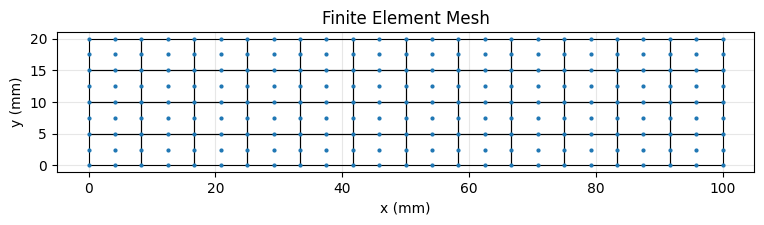

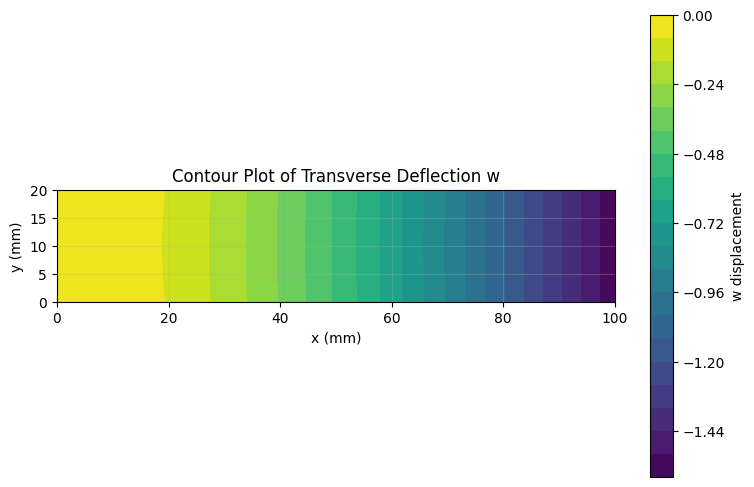

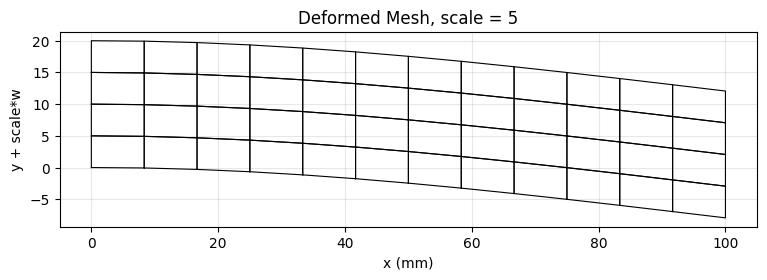

In [73]:
cantilever_results = run_cantilever_plate_strip_test(
    nx=12,
    ny=4,
    make_plots=True
)

In [74]:
# @title convergence
def run_cantilever_plate_strip_convergence():
    meshes = [
        (4, 2),
        (8, 4),
        (12, 4),
        (16, 6),
        (20, 8)
    ]

    results = []

    for nx, ny in meshes:
        res = run_cantilever_plate_strip_test(
            nx=nx,
            ny=ny,
            make_plots=False
        )

        results.append({
            "nx": nx,
            "ny": ny,
            "elements": len(res["elements"]),
            "ndof": res["ndof"],
            "w_tip_num": res["w_tip_num"],
            "w_tip_euler": res["w_tip_euler"],
            "w_tip_timoshenko": res["w_tip_timoshenko"],
            "error_timoshenko_percent": res["error_timoshenko_percent"]
        })

    print("\nCANTILEVER PLATE STRIP CONVERGENCE")
    print("-" * 110)
    print(
        f"{'nx':>5} {'ny':>5} {'elems':>8} {'ndof':>8} "
        f"{'w_num':>16} {'w_Timo':>16} {'error %':>12}"
    )
    print("-" * 110)

    for r in results:
        print(
            f"{r['nx']:5d} {r['ny']:5d} "
            f"{r['elements']:8d} {r['ndof']:8d} "
            f"{r['w_tip_num']:16.6e} "
            f"{r['w_tip_timoshenko']:16.6e} "
            f"{r['error_timoshenko_percent']:12.4f}"
        )

    print("-" * 110)

    # --------------------------------------------------------
    # Plot convergence
    # --------------------------------------------------------
    elems = np.array([r["elements"] for r in results])
    w_num = np.array([r["w_tip_num"] for r in results])
    w_timo = np.array([r["w_tip_timoshenko"] for r in results])
    w_euler = np.array([r["w_tip_euler"] for r in results])
    error = np.array([r["error_timoshenko_percent"] for r in results])

    plt.figure(figsize=(8, 5))
    plt.plot(elems, w_num, marker="o", label="FE numerical")
    plt.axhline(w_timo[0], linestyle="--", label="Timoshenko beam")
    plt.axhline(w_euler[0], linestyle=":", label="Euler-Bernoulli beam")
    plt.xlabel("Number of elements")
    plt.ylabel("Tip deflection")
    plt.title("Cantilever Plate Strip: Tip Deflection Convergence")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(elems, error, marker="o")
    plt.xlabel("Number of elements")
    plt.ylabel("Percent error vs. Timoshenko (%)")
    plt.title("Cantilever Plate Strip: Error Convergence")
    plt.grid(True, alpha=0.3)
    plt.show()

    return results


=== CANTILEVER PLATE STRIP LINE LOAD TEST ===

nx = 4, ny = 2
Number of elements = 8
ndof = 127
Total applied load numerical = -199.99999999999997
Total applied load exact = -200.0
Tip node = 27
Tip node coordinates = (np.float64(100.0), np.float64(10.0))
w_tip numerical = -1.5826554808341446
w_tip Euler-Bernoulli beam = -1.6
w_tip Timoshenko beam = -1.603
percent error vs Timoshenko = 1.2692%

=== CANTILEVER PLATE STRIP LINE LOAD TEST ===

nx = 8, ny = 4
Number of elements = 32
ndof = 427
Total applied load numerical = -199.99999999999997
Total applied load exact = -200.0
Tip node = 85
Tip node coordinates = (np.float64(100.0), np.float64(10.0))
w_tip numerical = -1.586974636027454
w_tip Euler-Bernoulli beam = -1.6
w_tip Timoshenko beam = -1.603
percent error vs Timoshenko = 0.9997%

=== CANTILEVER PLATE STRIP LINE LOAD TEST ===

nx = 12, ny = 4
Number of elements = 48
ndof = 627
Total applied load numerical = -199.99999999999997
Total applied load exact = -200.0
Tip node = 125
Tip n

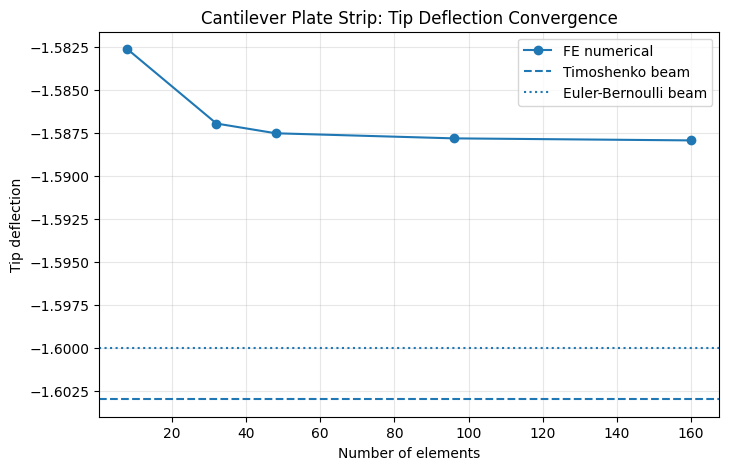

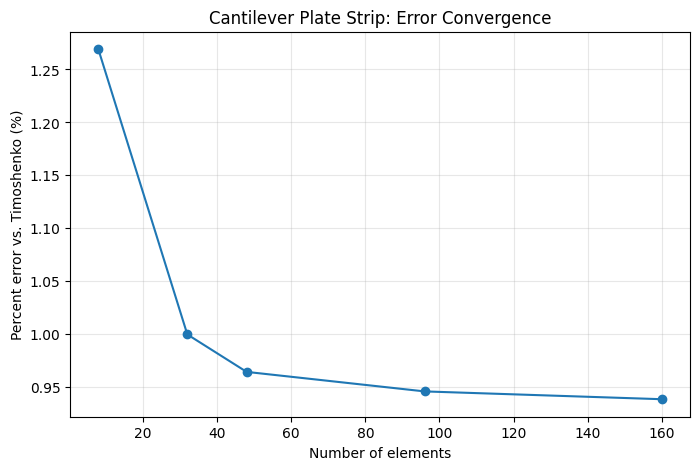

In [75]:
cantilever_convergence = run_cantilever_plate_strip_convergence()

### plots

In [76]:
# @title 3D deflection surface plot

from mpl_toolkits.mplot3d import Axes3D
from matplotlib.tri import Triangulation

def plot_w_3d_surface(nodes, dof_map, u, scale=1.0, figsize=(10, 7), title="3D Transverse Deflection Surface"):
    """
    Plots transverse deflection w as a 3D surface.

    x, y = plate coordinates
    z    = scaled transverse deflection

    This uses only nodes with active w DOFs.
    """

    x_vals = []
    y_vals = []
    w_vals = []

    for nid, data in nodes.items():
        if not data["active"]:
            continue

        d = dof_map[nid]

        if d["w"] is not None:
            x, y = data["coords"]
            w = u[d["w"]]

            x_vals.append(x)
            y_vals.append(y)
            w_vals.append(w)

    x_vals = np.array(x_vals)
    y_vals = np.array(y_vals)
    w_vals = np.array(w_vals)

    z_vals = scale * w_vals

    triang = Triangulation(x_vals, y_vals)

    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111, projection="3d")

    surf = ax.plot_trisurf(
        triang,
        z_vals,
        linewidth=0.2,
        antialiased=True,
        alpha=0.9
    )

    fig.colorbar(surf, ax=ax, shrink=0.6, label="w displacement")

    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.set_zlabel(f"{scale} × w")
    ax.set_title(title)

    plt.show()

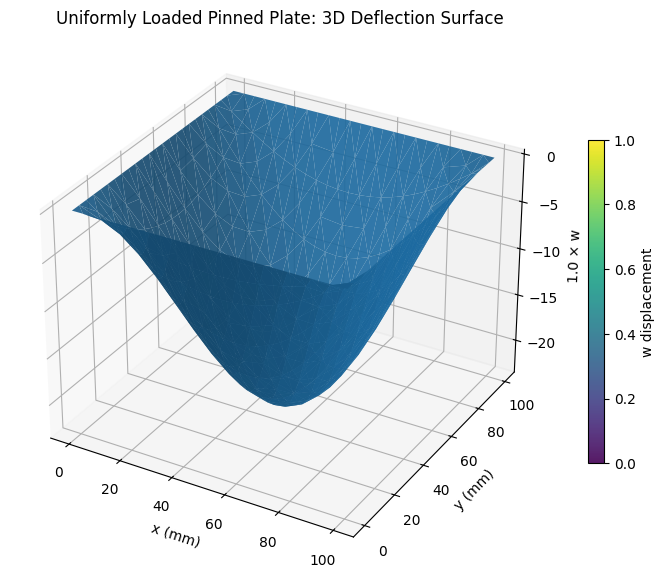

In [82]:
plot_w_3d_surface(
    nodes=ss_uniform_results["nodes"],
    dof_map=ss_uniform_results["dof_map"],
    u=ss_uniform_results["u"],
    scale=1.0,
    title="Uniformly Loaded Pinned Plate: 3D Deflection Surface"
    )

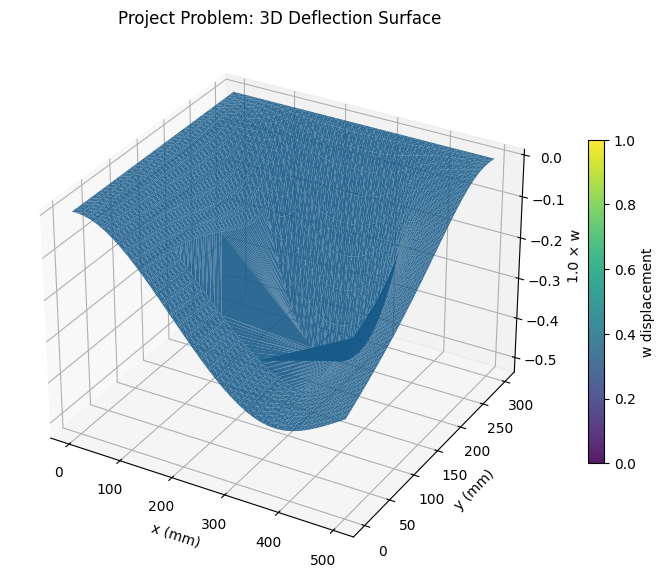

In [78]:
plot_w_3d_surface(
    nodes=results["nodes"],
    dof_map=results["dof_map"],
    u=results["u"],
    scale=1.0,
    title="Project Problem: 3D Deflection Surface"
)

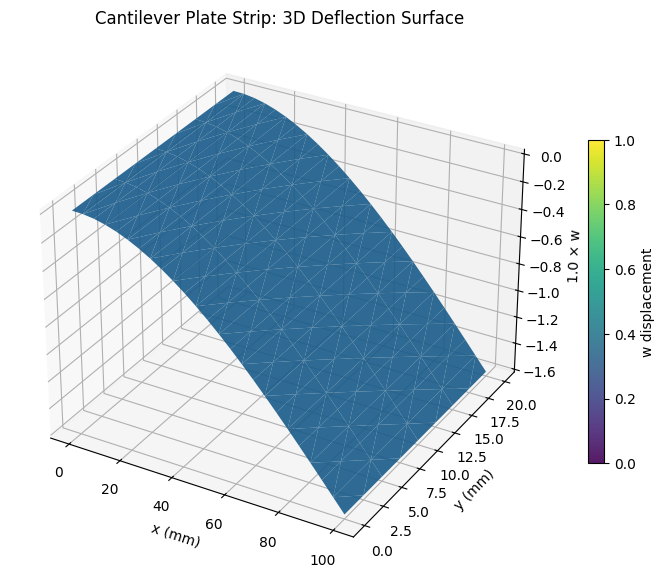

In [79]:
plot_w_3d_surface(
    nodes=cantilever_results["nodes"],
    dof_map=cantilever_results["dof_map"],
    u=cantilever_results["u"],
    scale=1.0,
    title="Cantilever Plate Strip: 3D Deflection Surface"
)